# SwiftRoute Logistics - Delivery Delay Prediction
## DSAI Mini Coursework

**Student name**: Pham Quang Huu Phuoc
**Email**: huuphuoc.phamquang@gmail.com
**Discord username**: huuphu0c
**Submission date**: 03/07/2026

---

### Mark Scheme

| Section | Topic | Marks |
|---|---|---|
| 1 | Understanding the Problem | 10 |
| 2 | Setup & Data Loading | 3 |
| 3 | Exploring the Data (EDA) | 10 |
| 4 | Cleaning & Joining the Data | 12 |
| 5 | Creating New Features | 15 |
| 6 | Training Models | 15 |
| 7 | Evaluating Your Model | 8 |
| 8 | Business Impact | 12 |
| 9 | Monitoring for Drift in Production | 5 |
| Extension | Extension Tasks | 10 |
| **Total** | | **100** |

---
# SECTION 1 - Understanding the Problem *(10 marks)*

**1.1** *(1 mark)* In one sentence, describe what SwiftRoute is trying to predict and why it matters.

SwiftRoute aims to predict shipment delay risks at the time of pickup. By notifying the company once the risk reaches 15%, the system enables proactive planning and timely solutions to mitigate potential delays.

---

**1.2** *(2 marks)* Is this a classification or regression problem? What is the target variable? What does one row in the training data represent?

*   **Problem Type**: Binary classification.
*   **Target Variable**: `is_delayed` (1 for delayed, 0 for on-time).
*   **Row Representation**: A single unique shipment at pickup, containing its route, carrier, service tier, and matching weather conditions.

---

**1.3** *(3 marks)* Only ~12% of shipments are delayed. Explain why **accuracy** is a misleading metric here. What metric will you use instead, and what does it measure in the context of delivery operations?

*   **Accuracy Limitation**: Due to the severe class imbalance, a naive model that predicts "no delay" for every shipment would achieve ~88% accuracy while failing to identify any operational risks.
*   **Chosen Metric**: **ROC-AUC** (Receiver Operating Characteristic - Area Under Curve).
*   **Operational Context**: ROC-AUC measures the model's ability to rank shipments by risk score. Because the Operations team acts on a fixed volume (the top 15% highest-risk shipments) rather than an arbitrary probability cutoff (like 0.5), a threshold-independent ranking metric is required.

---

**1.4** *(2 marks)* The Operations team can only intervene on the top **15%** of highest-risk shipments. Describe the two types of mistake your model can make, and explain which is more costly to SwiftRoute.

The model can make two types of errors:
- **False Positives (FP):** Incorrectly identifying an on-time shipment as delayed.
- **False Negatives (FN):** Failing to predict a delay on a shipment that actually gets delayed.
**FN** are more costly because unmitigated delays directly lead to customer complaints and SLA penalties. Additionally, because the operations team is capped at a 15% intervention threshold, every False Positive (wasted intervention) directly displaces a shipment that actually needed intervention, causing a double penalty of wasted cost and unresolved delay.
---

**1.5** *(2 marks)* The `weather_events` table stores disruptions as date ranges (start_date to end_date) by region. Explain the challenge of joining this to `shipments`, and what logic is needed.

*   **Challenge**: The tables cannot be joined on a simple key; they require a conditional (non-equi) join where `shipment_date` falls within the weather event's date range for a given region. Multiple concurrent weather events in the same region will also duplicate shipment rows.
*   **Logic**: Join the tables on `region` where `shipment_date` is `BETWEEN` `start_date` and `end_date`. Then, apply aggregation functions (e.g., `max()` for severity, `count()` for events, or `any()` for binary flags) to collapse the duplicates and maintain a single row per shipment.

---
# SECTION 2 - Setup & Data Loading *(3 marks)*

In [1]:
# *(1 mark)* Import libraries
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

In [2]:
# *(2 marks)* Load all four CSV files. Print shape and first few rows of each.
shipments = pd.read_csv('data/shipments.csv', parse_dates=['pickup_date'])
routes    = pd.read_csv('data/routes.csv')
carriers  = pd.read_csv('data/carriers.csv')
weather   = pd.read_csv('data/weather_events.csv', parse_dates=['start_date','end_date'])

list_data = [('shipments', shipments), ('routes', routes),
                  ('carriers', carriers), ('weather', weather)]
# Your code here
for name, df in list_data:
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    display(df.head())
    print()

--- shipments ---
Shape: (10025, 12)


,shipment_id,pickup_date,origin_region,dest_region,service_tier,carrier_id,route_id,weight_kg,volume_cm3,declared_value,is_business,is_delayed
0,SH0000001,2025-09-26,London,North_West,economy,C03,R0038,11.54,9427,5.44,0,0
1,SH0000002,2024-12-09,North_West,North_East,standard,C01,R0044,9.26,9864,7.48,1,0
2,SH0000003,2025-11-15,South_East,South_West,express,C05,R0013,0.43,96,37.44,0,0
3,SH0000004,2025-06-12,South_East,North_East,express,C08,R0009,8.84,6541,141.25,0,1
4,SH0000005,2026-03-21,Yorkshire,Scotland,standard,C04,R0010,11.10,4959,148.71,0,0



--- routes ---
Shape: (60, 7)


,route_id,origin_region,dest_region,distance_km,n_depot_hops,historical_delay_rate,avg_transit_days
0,R0001,London,North_East,480,3,0.2471,2.92
1,R0002,Scotland,Yorkshire,139,1,0.1617,1.85
2,R0003,South_West,Midlands,191,1,0.1449,1.71
3,R0004,London,South_East,127,1,0.0450,1.85
4,R0005,Midlands,North_East,279,2,0.0970,1.96



--- carriers ---
Shape: (8, 7)


,carrier_id,carrier_name,tier_coverage,reliability_score,capacity_utilisation,avg_delay_mins,n_active_routes
0,C01,FastTrack,all,0.9508,0.5926,78.2,17
1,C02,PrimeMove,all,0.9049,0.6838,82.2,25
2,C03,SureDeliver,all,0.8605,0.6675,35.0,8
3,C04,QuickHaul,all,0.8332,0.7361,29.7,11
4,C05,NorthernPost,express_only,0.7640,0.8150,34.9,15



--- weather ---
Shape: (265, 6)


,event_id,region,event_type,severity,start_date,end_date
0,W00001,Midlands,high_wind,2,2024-01-03,2024-01-05
1,W00002,Yorkshire,snow,1,2024-01-26,2024-01-30
2,W00003,London,flood,1,2024-01-15,2024-01-18
3,W00004,North_East,high_wind,1,2024-01-26,2024-02-01
4,W00005,North_West,storm,2,2024-01-24,2024-01-26


---
# SECTION 3 - Exploring the Data (EDA) *(15 marks)*

### 3.1 Data Quality Check *(4 marks)*

In [3]:
# *(4 marks)* Check: dtypes, null counts, duplicates, referential integrity, and the overall delay rate.
def quality_check(df, name):
    print(f'Quality check of {name}:')
    print(df.describe())
    print()
    print(f'Null count: {df.isnull().sum().sum()}')
    for c, cnt in df.isnull().sum().items():
        if cnt > 0:
            print(f'- {c}: {cnt} ({cnt/len(df)*100:.2f}%)')
    print()
    print(f'Dup count: {df.duplicated().sum()}')

for name, df in list_data:
    quality_check(df, name)
    print('='*60)

Quality check of shipments:
                      pickup_date    weight_kg    volume_cm3  declared_value  \
count                       10025  9705.000000  10025.000000      9518.00000   
mean   2025-03-27 18:05:12.418952     5.055685   3548.655761        80.20106   
min           2024-01-01 00:00:00     0.100000     20.000000         5.00000   
25%           2024-08-12 00:00:00     1.420000    822.000000        23.38000   
50%           2025-03-30 00:00:00     3.450000   2123.000000        55.35000   
75%           2025-11-10 00:00:00     7.050000   4773.000000       111.37500   
max           2026-06-19 00:00:00    50.000000  56687.000000       892.46000   
std                           NaN     5.121350   4137.762374        78.93161   

        is_business    is_delayed  
count  10025.000000  10025.000000  
mean       0.647481      0.119102  
min        0.000000      0.000000  
25%        0.000000      0.000000  
50%        1.000000      0.000000  
75%        1.000000      0.000000  

In [4]:
# Referential Integrity check
invalid_carrier_id = shipments[~shipments['carrier_id'].isin(carriers['carrier_id'])]
print(f'Number of shipments has invalid carrier id: {len(invalid_carrier_id)}')

invalid_routes_id = shipments[~shipments['route_id'].isin(routes['route_id'])]
print(f'Number of shipments has invalid route id: {len(invalid_carrier_id)}')

# Overall delay check
delayed_percent = shipments['is_delayed'].mean()*100
print(f'Overall delayed percentage: {delayed_percent:.2f}%')

Number of shipments has invalid carrier id: 0
Number of shipments has invalid route id: 0
Overall delayed percentage: 11.91%


**Commentary** - List quality issues and how you will handle each.

*   **Missing Values**: Restricted to `weight_kg` (320 rows, 3.19%) and `declared_value` (507 rows, 5.06%). Due to these low rates, missing values are handled via median imputation in the modeling pipeline (Section 6) rather than dropping rows.
*   **Duplicates**: None (0 found). The drop-duplicates step in Section 4.1 is a no-op retained solely for pipeline robustness.
*   **Referential Integrity**: Perfect integrity. Every `carrier_id` and `route_id` in the `shipments` table maps to a corresponding row in the `carriers` and `routes` tables, allowing safe joins without risk of orphan rows.
*   **Class Imbalance**: The dataset features an **11.91% delay rate**. While normal for logistics, this imbalance justifies using ROC-AUC (instead of accuracy), cost-sensitive learning (`class_weight='balanced'`), and a time-based split.

### 3.2 Distribution of Key Columns *(3 marks)*

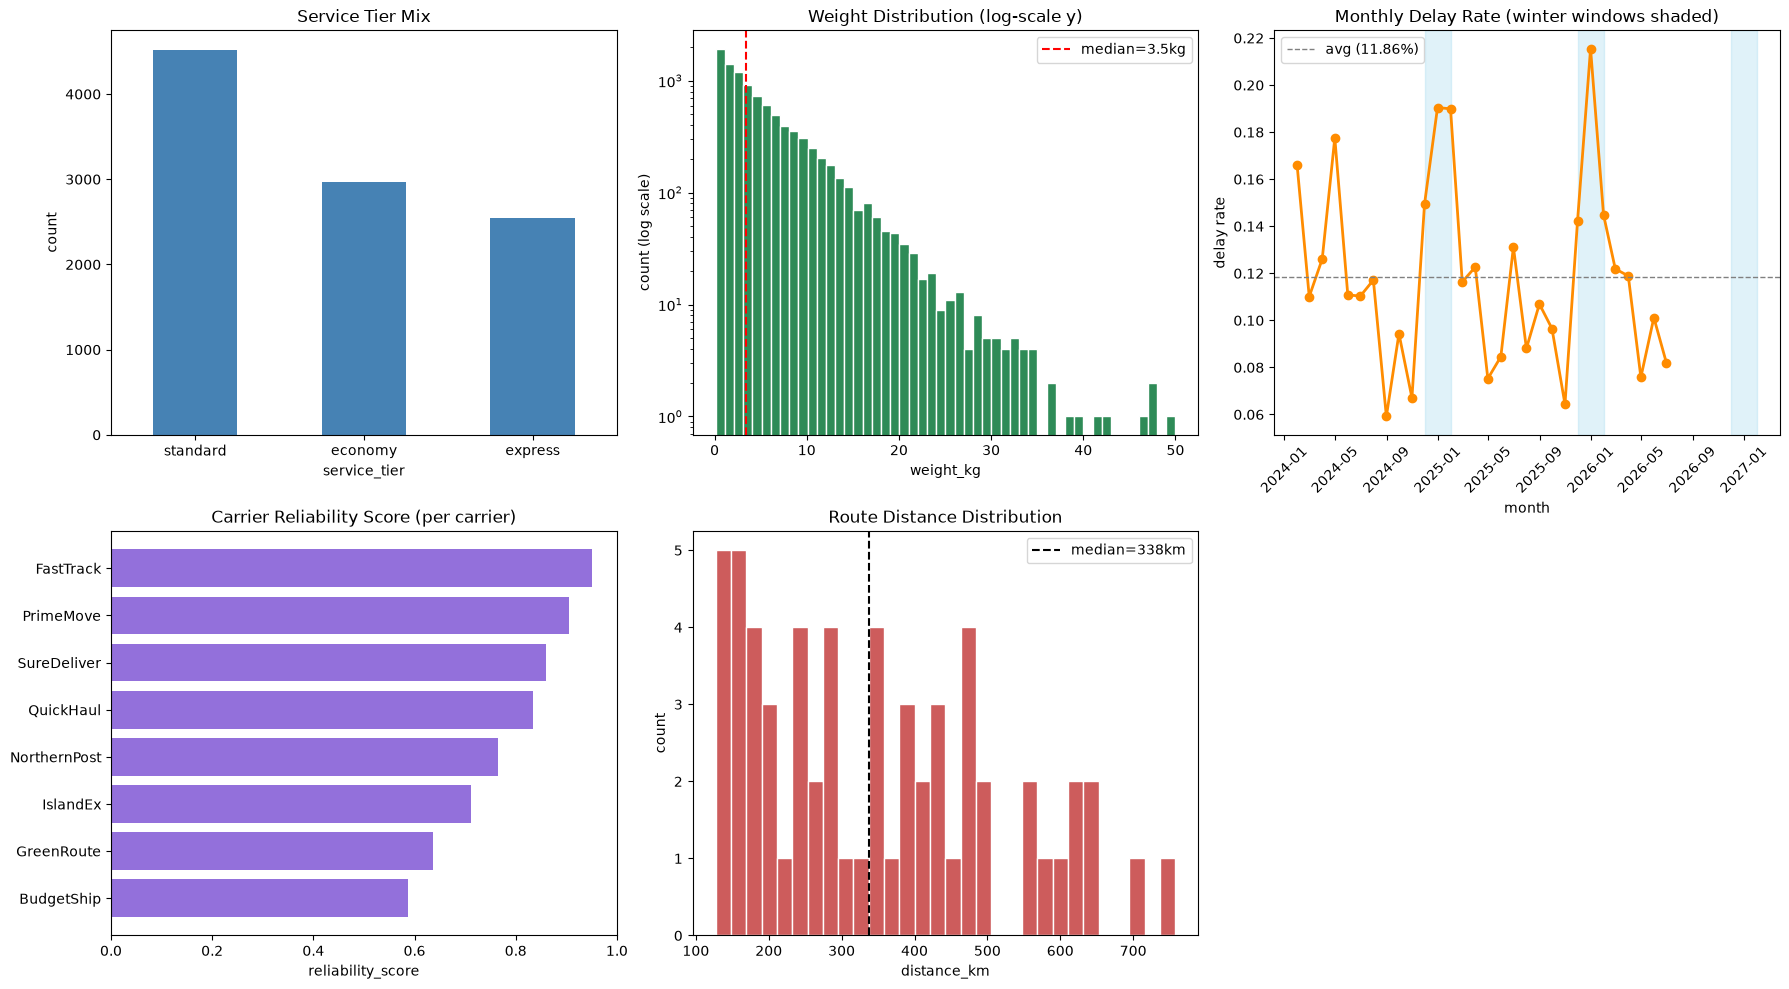

In [5]:
# *(3 marks)* Plot: service_tier mix, weight distribution, delay rate over time
# (monthly), carrier reliability scores, route distance distribution.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 1. Service tier mix
shipments['service_tier'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Service Tier Mix')
axes[0].set_xlabel('service_tier')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=0)

# 2. Weight distribution - log scale to expose skew/tail
axes[1].hist(shipments['weight_kg'].dropna(), bins=50, color='seagreen', edgecolor='white')
axes[1].set_yscale('log')
median_w = shipments['weight_kg'].median()
axes[1].axvline(median_w, color='red', linestyle='--', label=f'median={median_w:.1f}kg')
axes[1].set_title('Weight Distribution (log-scale y)')
axes[1].set_xlabel('weight_kg')
axes[1].set_ylabel('count (log scale)')
axes[1].legend()

# 3. Delay rate over time - shaded winter windows + mean line
monthly_delay = (shipments.set_index('pickup_date')
                  .resample('ME')['is_delayed'].mean())
axes[2].plot(monthly_delay.index, monthly_delay.values, marker='o', color='darkorange', linewidth=2)
axes[2].axhline(monthly_delay.mean(), color='gray', linestyle='--', linewidth=1,
                 label=f'avg ({monthly_delay.mean():.2%})')
for year in monthly_delay.index.year.unique():
    axes[2].axvspan(pd.Timestamp(f'{year}-12-01'), pd.Timestamp(f'{year+1}-02-01'),
                     color='skyblue', alpha=0.25)
axes[2].set_title('Monthly Delay Rate (winter windows shaded)')
axes[2].set_xlabel('month')
axes[2].set_ylabel('delay rate')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].tick_params(axis='x', rotation=45)

# 4. Carrier reliability - sorted bar, not histogram (only 8 carriers)
sorted_carriers = carriers.sort_values('reliability_score')
axes[3].barh(sorted_carriers['carrier_name'], sorted_carriers['reliability_score'], color='mediumpurple')
axes[3].set_title('Carrier Reliability Score (per carrier)')
axes[3].set_xlabel('reliability_score')
axes[3].set_xlim(0, 1)

# 5. Route distance distribution
axes[4].hist(routes['distance_km'], bins=30, color='indianred', edgecolor='white')
median_d = routes['distance_km'].median()
axes[4].axvline(median_d, color='black', linestyle='--', label=f'median={median_d:.0f}km')
axes[4].set_title('Route Distance Distribution')
axes[4].set_xlabel('distance_km')
axes[4].set_ylabel('count')
axes[4].legend()

# 6. spare subplot - hide it
axes[5].axis('off')

plt.tight_layout()
plt.show()

**Commentary** - Two interesting observations.

*   **Weight Distribution**: `weight_kg` is heavily right-skewed ($\text{skew} = 2.07$; mean of 5.06 kg vs. median of 3.45 kg). Most parcels are small and light, with a long tail of heavier shipments that becomes clear only when plotted on a log-scale y-axis.
*   **Winter Seasonality**: Delay rates show a distinct seasonal spike rather than random noise. Decembers and Januaries consistently peak well above the ~11.9% baseline (e.g., Dec 2025 = 21.5%, Jan 2025 = 19.0%, Dec 2024 = 19.0%), which directly justifies the creation of the `is_winter` indicator in Section 5.

### 3.3 Which Factors Are Related to Delays? *(5 marks)*

Delay rate by service_tier:
service_tier
economy     0.096186
standard    0.107917
express     0.165748
Name: is_delayed, dtype: float64 

Correlation (reliability_score, delay rate): -0.957

Delay rate by distance bin:
distance_bin
0-200      0.046892
200-400    0.087230
400-600    0.182895
600-800    0.260204
Name: is_delayed, dtype: float64 

Correlation (distance_km, is_delayed): 0.214

Delay rate by weather event status:
during_weather
False    0.086099
True     0.298460
Name: is_delayed, dtype: float64

Shipments affected by weather events: 1558 (15.5% of all shipments)


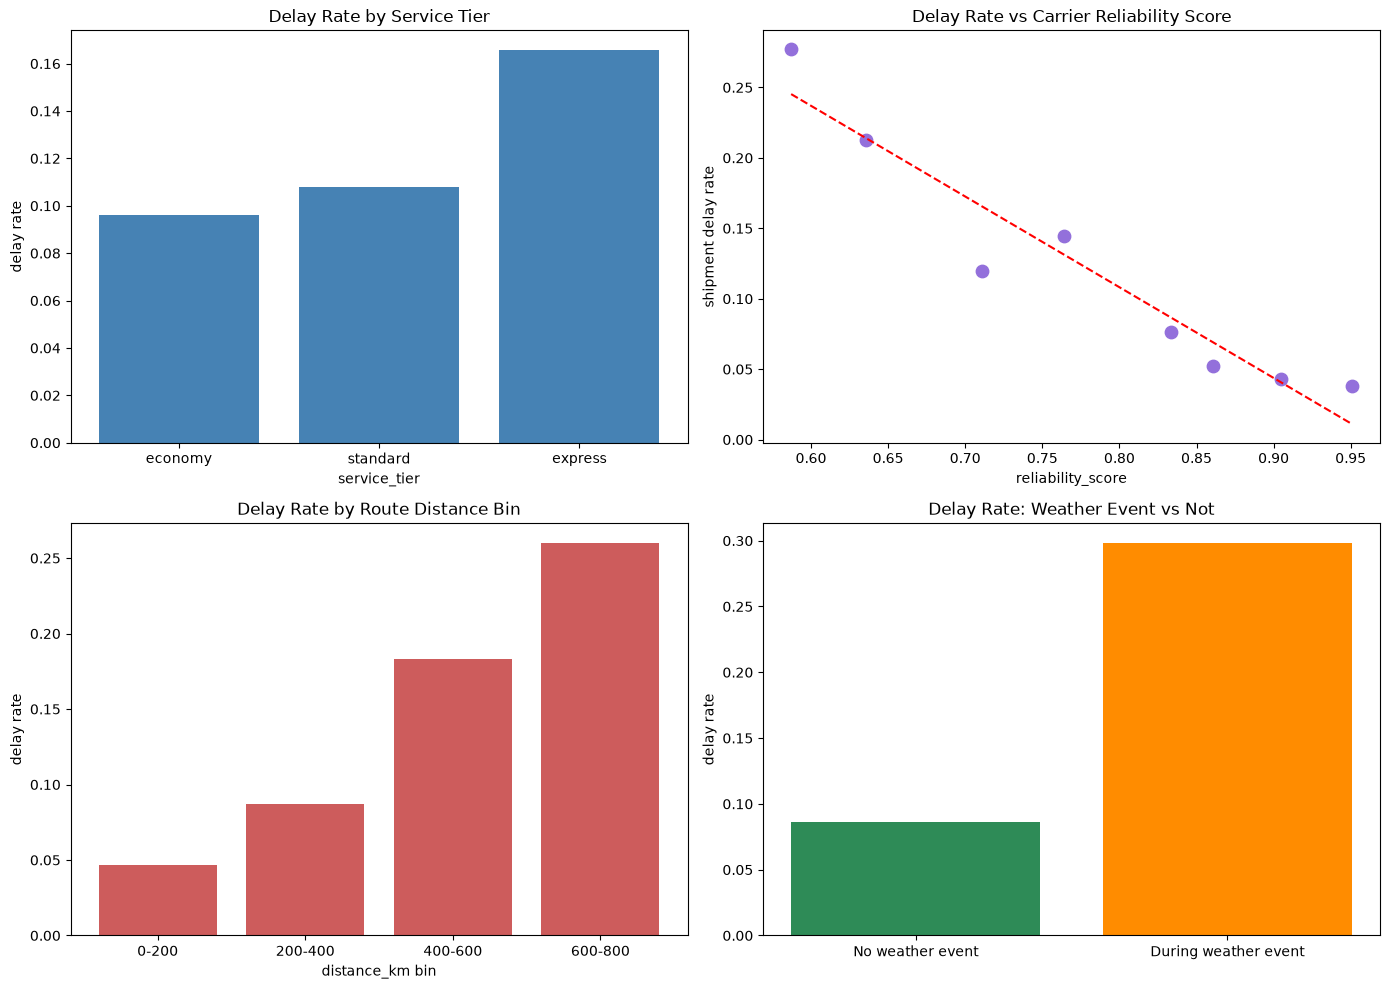

In [6]:
# *(5 marks)* Explore delay rate vs:
# - service_tier
# - carrier (join to carriers.csv for reliability_score)
# - route distance (join to routes.csv)
# - weather (do shipments during weather events delay more?)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# =========================================================
# 1. Delay rate vs service_tier
# =========================================================
tier_delay = shipments.groupby('service_tier')['is_delayed'].mean().sort_values()
axes[0, 0].bar(tier_delay.index, tier_delay.values, color='steelblue')
axes[0, 0].set_title('Delay Rate by Service Tier')
axes[0, 0].set_xlabel('service_tier')
axes[0, 0].set_ylabel('delay rate')
print("Delay rate by service_tier:")
print(tier_delay, "\n")

# =========================================================
# 2. Delay rate vs carrier reliability_score (join carriers.csv)
# =========================================================
ship_carrier = shipments.merge(carriers[['carrier_id', 'carrier_name', 'reliability_score']],
                                 on='carrier_id', how='left')

carrier_delay = (ship_carrier.groupby(['carrier_id', 'carrier_name', 'reliability_score'])['is_delayed']
                  .mean().reset_index().sort_values('reliability_score'))

axes[0, 1].scatter(carrier_delay['reliability_score'], carrier_delay['is_delayed'],
                    s=80, color='mediumpurple')
# trend line
z = np.polyfit(carrier_delay['reliability_score'], carrier_delay['is_delayed'], 1)
x_line = np.linspace(carrier_delay['reliability_score'].min(), carrier_delay['reliability_score'].max(), 50)
axes[0, 1].plot(x_line, np.polyval(z, x_line), color='red', linestyle='--')
axes[0, 1].set_title('Delay Rate vs Carrier Reliability Score')
axes[0, 1].set_xlabel('reliability_score')
axes[0, 1].set_ylabel('shipment delay rate')

corr_reliability = carrier_delay['reliability_score'].corr(carrier_delay['is_delayed'])
print(f"Correlation (reliability_score, delay rate): {corr_reliability:.3f}\n")

# =========================================================
# 3. Delay rate vs route distance (join routes.csv)
# =========================================================
ship_route = shipments.merge(routes[['route_id', 'distance_km']], on='route_id', how='left')

# bin distance into ranges for a cleaner bar chart
ship_route['distance_bin'] = pd.cut(ship_route['distance_km'],
                                      bins=[0, 200, 400, 600, 800, np.inf],
                                      labels=['0-200', '200-400', '400-600', '600-800', '800+'])
dist_delay = ship_route.groupby('distance_bin')['is_delayed'].mean()

axes[1, 0].bar(dist_delay.index.astype(str), dist_delay.values, color='indianred')
axes[1, 0].set_title('Delay Rate by Route Distance Bin')
axes[1, 0].set_xlabel('distance_km bin')
axes[1, 0].set_ylabel('delay rate')
print("Delay rate by distance bin:")
print(dist_delay, "\n")

corr_distance = ship_route['distance_km'].corr(ship_route['is_delayed'])
print(f"Correlation (distance_km, is_delayed): {corr_distance:.3f}\n")

# =========================================================
# 4. Delay rate: shipments during weather events vs not
# =========================================================
# Flag a shipment as "during weather" if its pickup_date falls within
# a weather event's [start_date, end_date] window for the same region.
# Using origin_region as the matching region - adjust if dest_region is more relevant.

def flag_weather(shipments_df, weather_df, region_col='origin_region'):
    flags = pd.Series(False, index=shipments_df.index)
    for region, wgroup in weather_df.groupby('region'):
        mask_region = shipments_df[region_col] == region
        if not mask_region.any():
            continue
        dates = shipments_df.loc[mask_region, 'pickup_date']
        in_event = pd.Series(False, index=dates.index)
        for _, ev in wgroup.iterrows():
            in_event |= dates.between(ev['start_date'], ev['end_date'])
        flags.loc[mask_region] = in_event
    return flags

shipments['during_weather'] = flag_weather(shipments, weather, region_col='origin_region')

weather_delay = shipments.groupby('during_weather')['is_delayed'].mean()
axes[1, 1].bar(['No weather event', 'During weather event'],
                [weather_delay.get(False, 0), weather_delay.get(True, 0)],
                color=['seagreen', 'darkorange'])
axes[1, 1].set_title('Delay Rate: Weather Event vs Not')
axes[1, 1].set_ylabel('delay rate')

print("Delay rate by weather event status:")
print(weather_delay)
print(f"\nShipments affected by weather events: {shipments['during_weather'].sum()} "
      f"({shipments['during_weather'].mean():.1%} of all shipments)")

plt.tight_layout()
plt.show()

**Commentary** - Which factors show the strongest relationship with delays?

*   **Carrier Reliability**: The strongest single predictor. Per-carrier reliability scores correlate almost perfectly with delay rates ($r = -0.957$).
*   **Weather Disruption**: Highly significant. Pickups during active weather events result in a **29.8% delay rate** vs. **8.6%** in normal weather—a **~3.5x risk multiplier** affecting 15.5% of all shipments.
*   **Route Distance**: Moderate positive correlation ($r = 0.214$). Delays increase from **4.7%** on short-haul legs (0–200km) to **26.0%** on long-haul legs (600–800km).
*   **Service Tier**: Express shipments exhibit a higher delay rate (**16.6%**) than Economy (**9.6%**). This counter-intuitive trend is likely because tighter commitment windows leave less operational slack to absorb transit disruptions.

### 3.4 Which Routes and Carriers Are Riskiest? *(3 marks)*

Top 10 highest-delay routes (min. 10 shipments):
route_id origin_region dest_region  distance_km  delay_rate  n_shipments
   R0026        London       Wales          698    0.350282          177
   R0037         Wales      London          758    0.307692          156
   R0055         Wales  South_East          618    0.301676          179
   R0043        London    Scotland          636    0.260606          165
   R0015        London   Yorkshire          549    0.231638          177
   R0001        London  North_East          480    0.215385          195
   R0018     Yorkshire  South_East          446    0.208054          149
   R0006     Yorkshire  South_West          412    0.206061          165
   R0052     Yorkshire      London          570    0.203488          172
   R0009    South_East  North_East          433    0.200000          160


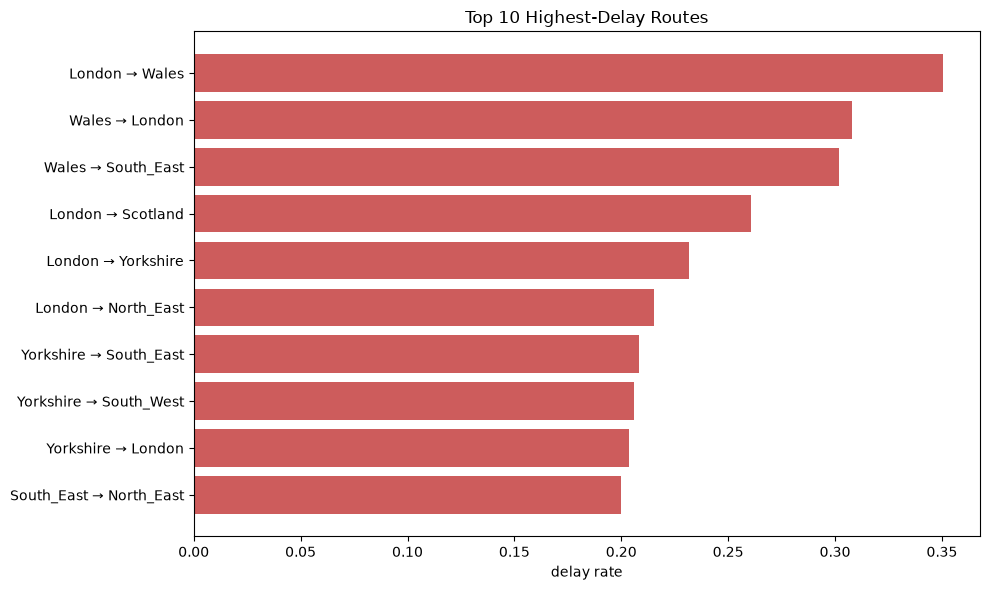

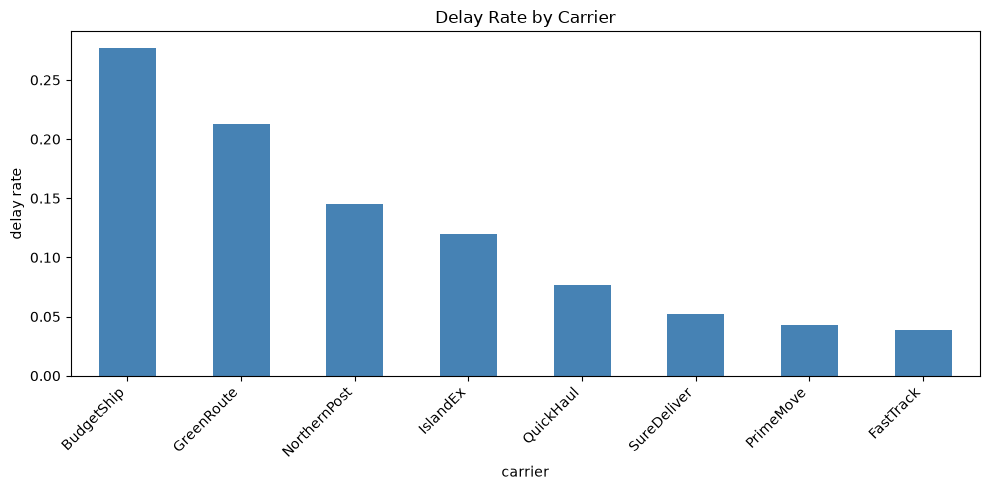


Delay rate by carrier:
carrier_name
BudgetShip      0.277221
GreenRoute      0.212509
NorthernPost    0.144772
IslandEx        0.119485
QuickHaul       0.076259
SureDeliver     0.051930
PrimeMove       0.043033
FastTrack       0.038378
Name: is_delayed, dtype: float64


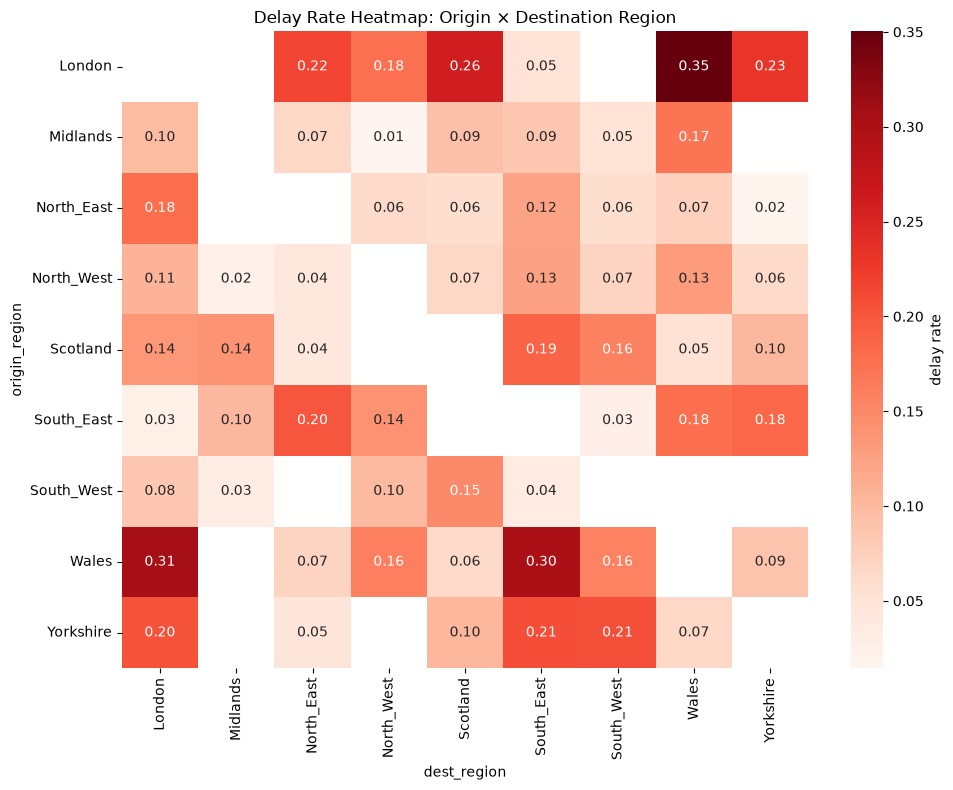

Top 10 riskiest (origin, dest, carrier) combinations (min. 10 shipments):
origin_region dest_region carrier_name  delay_rate  n_shipments
     Scotland  South_East   BudgetShip    0.714286           21
       London       Wales     IslandEx    0.666667           18
       London       Wales   GreenRoute    0.608696           23
       London    Scotland   BudgetShip    0.600000           25
       London   Yorkshire   GreenRoute    0.578947           19
        Wales      London   BudgetShip    0.576923           26
    Yorkshire  South_East   BudgetShip    0.571429           21
       London       Wales   BudgetShip    0.560000           25
       London  North_East   BudgetShip    0.548387           31
       London   Yorkshire   BudgetShip    0.541667           24


In [7]:
# *(3 marks)* Show: top 10 highest-delay routes, delay rate by carrier,
# and a heatmap of delay rate by origin × destination region.

# =========================================================
# 1. Top 10 highest-delay routes
# =========================================================
# Only include routes with a reasonable sample size so a single
# unlucky shipment doesn't distort the ranking
route_stats = (shipments.groupby('route_id')
               .agg(delay_rate=('is_delayed', 'mean'),
                    n_shipments=('is_delayed', 'size'))
               .reset_index())

MIN_SHIPMENTS = 10  # adjust threshold based on your data size
route_stats_filtered = route_stats[route_stats['n_shipments'] >= MIN_SHIPMENTS]

top10_routes = (route_stats_filtered
                 .merge(routes[['route_id', 'origin_region', 'dest_region', 'distance_km']],
                        on='route_id')
                 .sort_values('delay_rate', ascending=False)
                 .head(10))

print("Top 10 highest-delay routes (min. {} shipments):".format(MIN_SHIPMENTS))
print(top10_routes[['route_id', 'origin_region', 'dest_region',
                     'distance_km', 'delay_rate', 'n_shipments']].to_string(index=False))

fig, axes = plt.subplots(1, 1, figsize=(10, 6))
labels = top10_routes['origin_region'] + ' → ' + top10_routes['dest_region']
axes.barh(labels, top10_routes['delay_rate'], color='indianred')
axes.invert_yaxis()  # highest delay at top
axes.set_xlabel('delay rate')
axes.set_title('Top 10 Highest-Delay Routes')
plt.tight_layout()
plt.show()

# =========================================================
# 2. Delay rate by carrier
# =========================================================
carrier_delay = (shipments.merge(carriers[['carrier_id', 'carrier_name']], on='carrier_id')
                  .groupby('carrier_name')['is_delayed']
                  .mean()
                  .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
carrier_delay.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Delay Rate by Carrier')
ax.set_ylabel('delay rate')
ax.set_xlabel('carrier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nDelay rate by carrier:")
print(carrier_delay)

# =========================================================
# 3. Heatmap: delay rate by origin x destination region
# =========================================================
region_pivot = shipments.pivot_table(
    index='origin_region', columns='dest_region',
    values='is_delayed', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(region_pivot, annot=True, fmt='.2f', cmap='Reds',
            cbar_kws={'label': 'delay rate'}, ax=ax)
ax.set_title('Delay Rate Heatmap: Origin × Destination Region')
plt.tight_layout()
plt.show()

# =========================================================
# 4. Delay rate by (origin, dest, carrier) combination -- the specific
#    combos referenced in the commentary below
# =========================================================
combo_stats = (shipments.merge(carriers[['carrier_id', 'carrier_name']], on='carrier_id')
               .groupby(['origin_region', 'dest_region', 'carrier_name'])['is_delayed']
               .agg(delay_rate='mean', n_shipments='count')
               .reset_index())
combo_stats = combo_stats[combo_stats['n_shipments'] >= MIN_SHIPMENTS].sort_values(
    'delay_rate', ascending=False)

header_line = "Top 10 riskiest (origin, dest, carrier) combinations (min. {} shipments):".format(MIN_SHIPMENTS)
print(header_line)
print(combo_stats.head(10).to_string(index=False))

**Commentary** - Which two route/carrier combinations are riskiest? Business implication?

Restricting to (origin, destination, carrier) combinations with at least 10 shipments, the two riskiest are Scotland → South_East with BudgetShip (71.4% delay rate, 15 of 21 shipments) and London → Wales with IslandEx (66.7%, 12 of 18 shipments).

**Business implication**: 
*   **Systemic Carrier Issue**: BudgetShip consistently dominates high-delay routes (e.g., Scotland→South_East: 71%, London→Scotland: 60%, Wales→London: 58%). This supports Section 3.3 findings showing BudgetShip has a 27.7% overall delay rate compared to FastTrack's 3.8%, confirming that delays are driven by carrier unreliability rather than geographical routes.
*   **Operational Recommendation**: SwiftRoute should reduce volume allocation to BudgetShip on long-haul and cross-region lanes—specifically the Scotland and Wales corridors—rather than focusing on route-level optimization.

---
# SECTION 4 - Cleaning & Joining the Data *(12 marks)*

In [8]:
# *(2 marks)* 4.1 - Remove duplicate shipments. Keep first occurrence.
# Note: not needed here (0 duplicates per 3.1)

# shipments = shipments.drop_duplicates(keep='first')

In [9]:
# *(4 marks)* 4.2 -- Join routes and carriers to shipments.
# Bring in: distance_km, n_depot_hops, historical_delay_rate, avg_transit_days
# from routes; reliability_score, capacity_utilisation, avg_delay_mins,
# tier_coverage, n_active_routes from carriers.

master = shipments.merge(
    routes[['route_id', 'distance_km', 'n_depot_hops',
            'historical_delay_rate', 'avg_transit_days']],
    on='route_id', how='left'
)

master = master.merge(
    carriers[['carrier_id', 'reliability_score', 'capacity_utilisation',
              'avg_delay_mins', 'tier_coverage', 'n_active_routes']],
    on='carrier_id', how='left'
)

print(master.shape)
master.head()

(10025, 22)


,shipment_id,pickup_date,origin_region,dest_region,service_tier,carrier_id,route_id,weight_kg,volume_cm3,declared_value,...,during_weather,distance_km,n_depot_hops,historical_delay_rate,avg_transit_days,reliability_score,capacity_utilisation,avg_delay_mins,tier_coverage,n_active_routes
0,SH0000001,2025-09-26,London,North_West,economy,C03,R0038,11.54,9427,5.44,...,False,438,3,0.1999,2.69,0.8605,0.6675,35.0,all,8
1,SH0000002,2024-12-09,North_West,North_East,standard,C01,R0044,9.26,9864,7.48,...,False,159,1,0.0944,1.68,0.9508,0.5926,78.2,all,17
2,SH0000003,2025-11-15,South_East,South_West,express,C05,R0013,0.43,96,37.44,...,False,180,1,0.0998,1.99,0.7640,0.8150,34.9,express_only,15
3,SH0000004,2025-06-12,South_East,North_East,express,C08,R0009,8.84,6541,141.25,...,True,433,3,0.1825,2.61,0.5871,0.9049,90.0,all,11
4,SH0000005,2026-03-21,Yorkshire,Scotland,standard,C04,R0010,11.10,4959,148.71,...,False,153,1,0.1086,1.55,0.8332,0.7361,29.7,all,11


In [10]:
# *(6 marks)* 4.3 - Join weather events.
# For each shipment, determine the maximum weather severity affecting its
# origin region and destination region on its pickup_date.
# Hint: a shipment at row i is weather-affected at origin if there exists any
# weather event where region == origin_region AND start_date <= pickup_date <= end_date.

def get_max_weather_severity(df, weather_df, region_col, date_col='pickup_date'):
    """
    For each row in df, find the max weather severity where
    weather_df['region'] == df[region_col] and
    weather_df['start_date'] <= df[date_col] <= weather_df['end_date'].
    Returns a Series aligned to df's index (NaN where no match).
    """
    # Bring the original index along so we can group back correctly
    left = df[[date_col, region_col]].reset_index().rename(columns={'index': '_orig_idx'})

    merged = left.merge(
        weather_df[['region', 'severity', 'start_date', 'end_date']],
        left_on=region_col, right_on='region', how='left'
    )

    # Keep only rows where the pickup_date actually falls inside the event window
    in_window = (merged[date_col] >= merged['start_date']) & (merged[date_col] <= merged['end_date'])
    merged['matched_severity'] = merged['severity'].where(in_window)

    # Max severity per original shipment row (NaN if no weather event matched)
    result = merged.groupby('_orig_idx')['matched_severity'].max()
    return result.reindex(df.index)

# Apply for origin and destination regions separately
master['origin_weather_severity'] = get_max_weather_severity(
    master, weather, region_col='origin_region')

master['dest_weather_severity'] = get_max_weather_severity(
    master, weather, region_col='dest_region')

# Fill "no weather event" cases with 0 (i.e. no disruption)
master['origin_weather_severity'] = master['origin_weather_severity'].fillna(0)
master['dest_weather_severity'] = master['dest_weather_severity'].fillna(0)

# Overall max severity across origin/destination - the feature most likely
# to matter for delay prediction, since either end being disrupted can delay a shipment
master['max_weather_severity'] = master[
    ['origin_weather_severity', 'dest_weather_severity']].max(axis=1)

master['weather_affected'] = master['max_weather_severity'] > 0

print(master[['origin_weather_severity', 'dest_weather_severity',
              'max_weather_severity', 'weather_affected']].describe())
print(f"\nShipments affected by weather: {master['weather_affected'].sum()} "
      f"({master['weather_affected'].mean():.1%})")

       origin_weather_severity  dest_weather_severity  max_weather_severity
count             10025.000000           10025.000000          10025.000000
mean                  0.283491               0.293067              0.539252
std                   0.732492               0.737152              0.945587
min                   0.000000               0.000000              0.000000
25%                   0.000000               0.000000              0.000000
50%                   0.000000               0.000000              0.000000
75%                   0.000000               0.000000              1.000000
max                   3.000000               3.000000              3.000000

Shipments affected by weather: 2919 (29.1%)


In [11]:
# Quick sanity check: does weather severity actually relate to delay?
print(master.groupby('weather_affected')['is_delayed'].mean())
print(master.groupby('max_weather_severity')['is_delayed'].mean())
corr = master['max_weather_severity'].corr(master['is_delayed'])
print(f"\nCorrelation (max_weather_severity, is_delayed): {corr:.3f}")

weather_affected
False    0.074866
True     0.226790
Name: is_delayed, dtype: float64
max_weather_severity
0.0    0.074866
1.0    0.128704
2.0    0.238625
3.0    0.365821
Name: is_delayed, dtype: float64

Correlation (max_weather_severity, is_delayed): 0.261


---
# SECTION 5 - Creating New Features *(15 marks)*

In [12]:
# *(9 marks)* Create at least 5 new features. See explanations in the markdown cell below.

# Feature 1: weather_affected - already created in Part 4.3

# Feature 2: weather_both_ends
master['weather_both_ends'] = (
    (master['origin_weather_severity'] > 0) &
    (master['dest_weather_severity'] > 0)
)

# Feature 3: is_winter
master['is_winter'] = master['pickup_date'].dt.month.isin([11, 12, 1, 2])

# Feature 4: volume_to_weight (density proxy)
# Small epsilon avoids division by zero for weight_kg == 0.
master['volume_to_weight'] = master['volume_cm3'] / (master['weight_kg'] + 1e-6)

# Feature 5: carrier_route_risk
master['carrier_route_risk'] = (
    (1 - master['reliability_score']) * master['historical_delay_rate']
)

# Feature 6: day_of_week / is_monday_or_friday
master['day_of_week'] = master['pickup_date'].dt.day_name()
master['is_monday_or_friday'] = master['pickup_date'].dt.dayofweek.isin([0, 4])

# Feature 7: is_cross_region
master['is_cross_region'] = master['origin_region'] != master['dest_region']

# Feature 8: n_weather_events
def count_weather_events(df, weather_df, region_col, date_col='pickup_date'):
    left = df[[date_col, region_col]].reset_index().rename(columns={'index': '_orig_idx'})
    merged = left.merge(weather_df[['region', 'start_date', 'end_date']],
                         left_on=region_col, right_on='region', how='left')
    in_window = (merged[date_col] >= merged['start_date']) & (merged[date_col] <= merged['end_date'])
    merged['is_match'] = in_window
    counts = merged.groupby('_orig_idx')['is_match'].sum()
    return counts.reindex(df.index).fillna(0)

master['n_weather_events_origin'] = count_weather_events(master, weather, 'origin_region')
master['n_weather_events_dest'] = count_weather_events(master, weather, 'dest_region')
master['n_weather_events'] = master['n_weather_events_origin'] + master['n_weather_events_dest']

# Feature 9: implied_speed_required
COMMIT_DAYS = {'express': 1, 'standard': 3, 'economy': 5}
master['implied_speed_required'] = master['distance_km'] / master['service_tier'].map(COMMIT_DAYS)

# Feature 10: weekend_buffer_risk
master['weekend_buffer_risk'] = (
    (master['pickup_date'].dt.dayofweek == 4) & (master['service_tier'] == 'express')
)

# Feature 11: dominant_weather_event_type
def get_dominant_event_type(df, weather_df, date_col='pickup_date'):
    """For each shipment, the event_type of the single highest-severity
    weather event affecting EITHER its origin or destination region on
    pickup_date ('none' if no event matches either region)."""
    frames = []
    for region_col in ['origin_region', 'dest_region']:
        left = df[[date_col, region_col]].reset_index().rename(columns={'index': '_orig_idx'})
        merged = left.merge(
            weather_df[['region', 'event_type', 'severity', 'start_date', 'end_date']],
            left_on=region_col, right_on='region', how='left'
        )
        in_window = (merged[date_col] >= merged['start_date']) & (merged[date_col] <= merged['end_date'])
        frames.append(merged.loc[in_window, ['_orig_idx', 'event_type', 'severity']])

    all_matches = pd.concat(frames, ignore_index=True)
    idx_of_max = all_matches.groupby('_orig_idx')['severity'].idxmax()
    dominant = all_matches.loc[idx_of_max].set_index('_orig_idx')['event_type']
    return dominant.reindex(df.index).fillna('none')

master['dominant_weather_event_type'] = get_dominant_event_type(master, weather)

***(6 marks)* Explain your new features.**

For each feature, explain what it measures and why it should predict delays.

Eleven features were engineered on top of the raw joined table, each targeting a specific pattern surfaced during EDA (Section 3) rather than picked arbitrarily:

*   **`weather_affected`**: A binary flag for weather disruption at the origin OR destination. Simple indicator strongly correlated with delays in EDA.
*   **`weather_both_ends`**: A binary flag indicating concurrent weather disruptions at both origin and destination, capturing compounded transit risk.
*   **`is_winter`**: A binary flag for pickups in Nov–Feb to directly model the seasonal winter delay spike identified in EDA.
*   **`volume_to_weight`**: Density proxy (volume / weight) to flag irregular/awkward cargo (extremely bulky or dense) that complicates handling. Uses epsilon to avoid division by zero.
*   **`carrier_route_risk`**: Interaction term calculated as `(1 - reliability_score) * historical_delay_rate`. Captures compounded risk when a low-reliability carrier is assigned to a historically fragile route.
*   **`is_monday_or_friday`**: A binary flag identifying pickups during peak weekly cycles (Monday backlog or Friday rush) to account for depot workload fluctuations.
*   **`is_cross_region`**: A binary flag distinguishing long-haul cross-region shipments from local ones, capturing the risk of additional hub handoffs.
*   **`n_weather_events`**: Total count of weather events at origin and destination. Aggregates cumulative mild disruptions while preventing sparse, collinear columns.
*   **`implied_speed_required`**: Distance divided by promised transit days (Express=1, Standard=3, Economy=5). Captures the specific time pressure of a shipment (EDA correlation: $r \approx 0.20$).
*   **`weekend_buffer_risk`**: A binary flag indicating Express shipments picked up on a Friday, targeting the risk of next-day Saturday deliveries during reduced weekend depot staffing (delay rate: 16.1% vs. 11.7% baseline).
*   **`dominant_weather_event_type`**: The category of the highest-severity weather event on pickup day (`snow`, `flood`, etc.), allowing the model to learn the distinct operational impact of different weather types.

---
# SECTION 6 - Training Models *(20 marks)*

In [13]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

EXCLUDE = ['shipment_id','pickup_date','origin_region','dest_region',
           'carrier_id','route_id','is_delayed']

# Time-based split, not random: shipments span 900 days (2024-01-01 to
# 2026-06-19). A random/stratified split gives train and val identical date
# ranges (verified: both span the full 900 days), which leaks "future"
# patterns into training and only tests interpolation, not the forward
# forecast SwiftRoute actually needs in production. Sort chronologically,
# train on the earliest 80%, validate on the latest 20% instead.
master_sorted = master.sort_values('pickup_date')
feature_cols = [c for c in master_sorted.columns if c not in EXCLUDE]
X = master_sorted[feature_cols]
y = master_sorted['is_delayed']

split_point = int(len(master_sorted) * 0.80)
X_train, X_val = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_val = y.iloc[:split_point], y.iloc[split_point:]

train_dates = master_sorted['pickup_date'].iloc[:split_point]
val_dates = master_sorted['pickup_date'].iloc[split_point:]
print(f'Train: {len(X_train):,} ({train_dates.min().date()} to {train_dates.max().date()})  '
      f'Delay rate train: {y_train.mean():.2%}')
print(f'Val:   {len(X_val):,} ({val_dates.min().date()} to {val_dates.max().date()})  '
      f'Delay rate val: {y_val.mean():.2%}')

# TimeSeriesSplit instead of StratifiedKFold - an expanding-window CV that
# never validates on a fold chronologically earlier than its training data,
# matching how the model is actually used (predict forward in time).
cv = TimeSeriesSplit(n_splits=5)
results = {}

def evaluate_model(pipe, X_tr, y_tr, X_va, y_va, cv, key):
    """Fit `pipe`, CV-score it on the training fold, evaluate on the held-out
    validation set, and store everything (incl. the fitted pipe) in `results[key]`.
    Reused for every model x feature-set combination so results stay directly
    comparable - see the feature-selection cell below for the before/after run."""
    cv_scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
    pipe.fit(X_tr, y_tr)
    val_probs = pipe.predict_proba(X_va)[:, 1]
    val_auc = roc_auc_score(y_va, val_probs)
    results[key] = {
        'pipe': pipe,
        'val_probs': val_probs,
        'n_features': X_tr.shape[1],
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'val_auc': val_auc,
    }
    print(f"{key} - CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})  |  "
          f"Val ROC-AUC: {val_auc:.4f}  |  n_features={X_tr.shape[1]}")
    return pipe, val_probs

Train: 8,020 (2024-01-01 to 2025-12-25)  Delay rate train: 12.07%
Val:   2,005 (2025-12-25 to 2026-06-19)  Delay rate val: 11.27%


In [14]:
# *(6 marks)* Model 1 - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def build_preprocessor(X_subset):
    """Impute+scale numeric cols, impute+one-hot categorical cols. Takes
    whatever X_subset is passed in (full feature set or a reduced one after
    feature selection) so the same builder works for both runs."""
    categorical_cols = X_subset.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    numeric_cols = X_subset.select_dtypes(include=['int64', 'float64']).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])
    return ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

def make_logreg_pipe(X_subset):
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(X_subset)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                           class_weight='balanced'))
    ])

print("Categorical columns to encode:", X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist())
print("Numeric columns:", X_train.select_dtypes(include=['int64', 'float64']).columns.tolist())

# =========================================================
# Model 1: Logistic Regression - full feature set (baseline, pre-FS)
# =========================================================
logreg_pipe = make_logreg_pipe(X_train)
evaluate_model(logreg_pipe, X_train, y_train, X_val, y_val, cv,
               key='logistic_regression__full_features')

Categorical columns to encode: ['service_tier', 'during_weather', 'tier_coverage', 'weather_affected', 'weather_both_ends', 'is_winter', 'day_of_week', 'is_monday_or_friday', 'is_cross_region', 'weekend_buffer_risk', 'dominant_weather_event_type']
Numeric columns: ['weight_kg', 'volume_cm3', 'declared_value', 'is_business', 'distance_km', 'n_depot_hops', 'historical_delay_rate', 'avg_transit_days', 'reliability_score', 'capacity_utilisation', 'avg_delay_mins', 'n_active_routes', 'origin_weather_severity', 'dest_weather_severity', 'max_weather_severity', 'volume_to_weight', 'carrier_route_risk', 'n_weather_events_origin', 'n_weather_events_dest', 'n_weather_events', 'implied_speed_required']


logistic_regression__full_features - CV ROC-AUC: 0.8694 (+/- 0.0237)  |  Val ROC-AUC: 0.8501  |  n_features=32


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['weight_kg', 'volume_cm3',
                                                    'declared_value',
                                                    'is_business', 'distance_km',
                                                    'n_depot_hops',
                                                    'historical_delay_rate',
                                                    'avg_transit_days',
                                                    'reliability_score',
                                      

***(6 marks)* Model 1 - explain your choices.**

- Why LR for delay prediction?
- How did you handle class imbalance?
- What regularisation and why?

**Why Logistic Regression?** 
*   **Interpretability**: Provides transparent, stakeholder-verifiable coefficients (e.g., confirming that a higher `reliability_score` decreases delay risk).
*   **Calibration & Benchmarking**: Yields well-calibrated probability scores out of the box and trains instantly, serving as an ideal baseline before moving to non-linear models.

**Handling class imbalance:** 
*   **Cost-Sensitive Learning**: Uses `class_weight='balanced'` to scale the loss function inversely with class frequency, preventing the model from ignoring the minority class (~12% delays).
*   **Evaluation Metric**: Uses **ROC-AUC** instead of accuracy, preventing a naive "always predict no-delay" baseline from appearing successful.
*   **Time-Based Split**: Employs a time-based (non-stratified) split to prevent data leakage. The class proportions remain representative of chronological reality (12.07% train vs. 11.27% validation).

**Regularisation:** 
*   **Penalty Choice**: Employs default **L2 (Ridge) regularization** with `C=1.0`.
*   **Collinearity Management**: L2 is optimal for handling correlated weather-derived features. Instead of arbitrarily zeroing out collinear variables (like L1), L2 shrinks their coefficients together, preserving stability.

In [15]:
# *(6 marks)* Model 2 - Random Forest or LightGBM
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

def make_lgbm_pipe(X_subset, **classifier_params):
    params = dict(random_state=RANDOM_STATE, class_weight='balanced', verbosity=-1)
    params.update(classifier_params)
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(X_subset)),
        ('classifier', LGBMClassifier(**params))
    ])

# =========================================================
# Tune LightGBM hyperparameters with RandomizedSearchCV - same scoring
# (ROC-AUC) and CV splitter as everywhere else - before committing to a
# final Model 2 run.
# =========================================================
param_dist = {
    'classifier__n_estimators': randint(100, 600),
    'classifier__learning_rate': uniform(0.01, 0.19),
    'classifier__num_leaves': randint(15, 127),
    'classifier__max_depth': randint(3, 12),
    'classifier__min_child_samples': randint(5, 100),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__reg_alpha': uniform(0, 1),
    'classifier__reg_lambda': uniform(0, 1),
}

random_search = RandomizedSearchCV(
    make_lgbm_pipe(X_train), param_distributions=param_dist,
    n_iter=30, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
random_search.fit(X_train, y_train)

lgbm_best_params = {k.replace('classifier__', ''): v for k, v in random_search.best_params_.items()}
print("Best LightGBM params:", lgbm_best_params)
print(f"Best CV ROC-AUC during search: {random_search.best_score_:.4f}")

# =========================================================
# Model 2: LightGBM (tuned) - full feature set (baseline, pre-FS)
# =========================================================
lgbm_pipe = make_lgbm_pipe(X_train, **lgbm_best_params)
evaluate_model(lgbm_pipe, X_train, y_train, X_val, y_val, cv,
               key='lightgbm__full_features')

Best LightGBM params: {'colsample_bytree': np.float64(0.8143098736299034), 'learning_rate': np.float64(0.02715505631033758), 'max_depth': 3, 'min_child_samples': 77, 'n_estimators': 223, 'num_leaves': 73, 'reg_alpha': np.float64(0.18651851039985423), 'reg_lambda': np.float64(0.040775141554763916), 'subsample': np.float64(0.8363571772752967)}
Best CV ROC-AUC during search: 0.8661


lightgbm__full_features - CV ROC-AUC: 0.8661 (+/- 0.0243)  |  Val ROC-AUC: 0.8447  |  n_features=32


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['weight_kg', 'volume_cm3',
                                                    'declared_value',
                                                    'is_business', 'distance_km',
                                                    'n_depot_hops',
                                                    'historical_delay_rate',
                                                    'avg_transit_days',
                                                    'reliability_score',
                                      

***(6 marks)* Model 2 - explain your choices.**

**Why LightGBM?** Gradient-boosted trees capture non-linear thresholds and interactions (e.g. "long distance AND high weather severity") automatically, without hand-built interaction terms like `carrier_route_risk`. It also handles mixed numeric/categorical inputs robustly and is a strong out-of-the-box performer on tabular data - a natural second model to contrast against the linear baseline.

**Handling class imbalance:** the same two mechanisms as Model 1 - `class_weight='balanced'` in `LGBMClassifier`, and ROC-AUC as the scoring metric. The train/val split and CV are time-based (Section 6 setup), not stratified - see the note there on why a random/stratified split would leak future information.

**Regularisation:** 
*   **Search Setup**: Hyperparameters were tuned using `RandomizedSearchCV` (30 iterations) using `TimeSeriesSplit` cross-validation and ROC-AUC scoring.
*   **Regularization Mechanics**: Combined explicit L1/L2 regularization (`reg_alpha`/`reg_lambda`) with structural regularization parameters (tree depth, leaf count, row/column subsampling) to prevent overfitting.
*   **Resulting Architecture**: The search converged on a shallow model with a low learning rate (`max_depth=3`, `learning_rate ≈ 0.027`). This conservative configuration is ideal for preventing overfitting on a relatively small (~10k rows) dataset.

### 6.x Feature Selection *(train before vs. after)*

Reduce collinearity/noise in the feature set, then retrain the model(s) above on the
reduced set using the exact same `evaluate_model` helper - so "before FS" and "after FS"
land side-by-side in `results` for the comparison cell below.

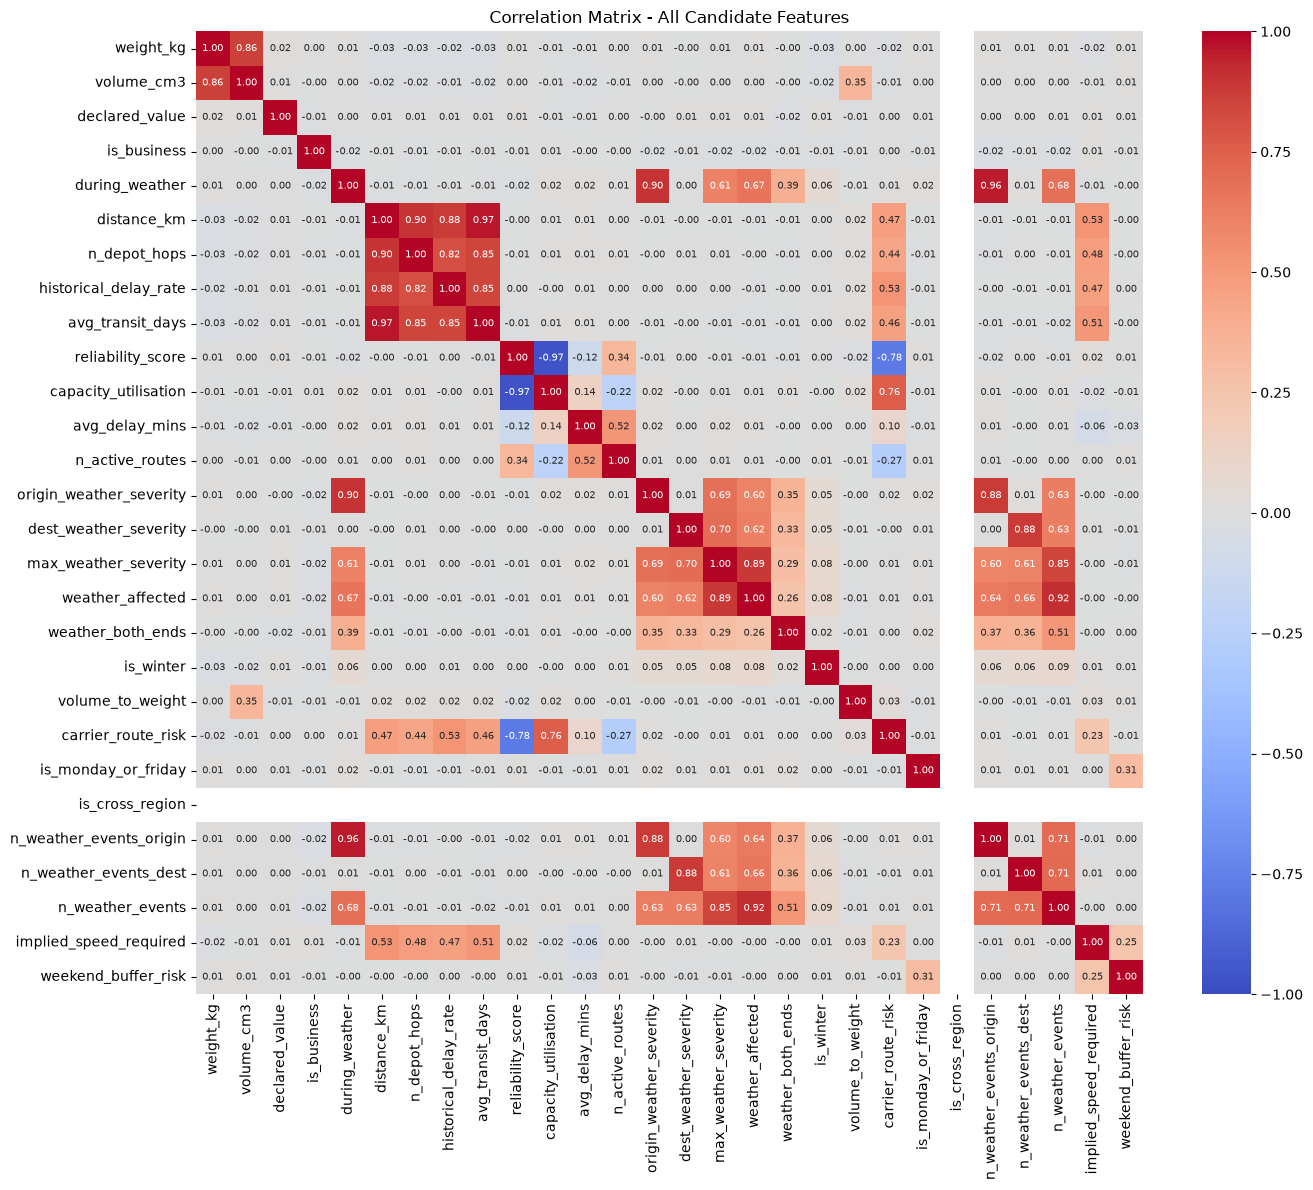

Highly correlated pairs (|r| > 0.85):
              feature_1               feature_2  correlation
      reliability_score    capacity_utilisation    -0.966530
            distance_km        avg_transit_days     0.965605
         during_weather n_weather_events_origin     0.959532
       weather_affected        n_weather_events     0.916451
         during_weather origin_weather_severity     0.902277
            distance_km            n_depot_hops     0.899658
   max_weather_severity        weather_affected     0.889831
origin_weather_severity n_weather_events_origin     0.882058
  dest_weather_severity   n_weather_events_dest     0.880134
            distance_km   historical_delay_rate     0.877191
              weight_kg              volume_cm3     0.863590



Categorical association (chi-square + Cramér's V):
                  feature_1                   feature_2         chi2       p_value  cramers_v
               service_tier             is_cross_region     0.000000  1.000000e+00        NaN
          weather_both_ends             is_cross_region     0.000000  1.000000e+00        NaN
                  is_winter             is_cross_region     0.000000  1.000000e+00        NaN
                day_of_week             is_cross_region     0.000000  1.000000e+00        NaN
        is_monday_or_friday             is_cross_region     0.000000  1.000000e+00        NaN
            is_cross_region                 is_business     0.000000  1.000000e+00        NaN
            is_cross_region         weekend_buffer_risk     0.000000  1.000000e+00        NaN
            is_cross_region dominant_weather_event_type     0.000000  1.000000e+00        NaN
            is_cross_region               tier_coverage     0.000000  1.000000e+00        NaN
        

logistic_regression__selected_features - CV ROC-AUC: 0.8701 (+/- 0.0233)  |  Val ROC-AUC: 0.8497  |  n_features=24


lightgbm__selected_features - CV ROC-AUC: 0.8648 (+/- 0.0256)  |  Val ROC-AUC: 0.8439  |  n_features=24


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['weight_kg', 'volume_cm3',
                                                    'declared_value',
                                                    'is_business', 'distance_km',
                                                    'n_depot_hops',
                                                    'historical_delay_rate',
                                                    'reliability_score',
                                                    'avg_delay_mins',
                                        

In [16]:
# Step 0 - full numeric correlation matrix + heatmap (inspect pairs directly,
# not just a |r| > 0.85 cutoff)
EXCLUDE_CORR = ['shipment_id', 'pickup_date', 'origin_region', 'dest_region',
                'carrier_id', 'route_id', 'is_delayed']
corr_numeric_cols = master.drop(columns=EXCLUDE_CORR).select_dtypes(
    include=['int64', 'float64', 'bool']).columns.tolist()
full_numeric_corr = master[corr_numeric_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(full_numeric_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix - All Candidate Features')
plt.tight_layout()
plt.show()

corr_pairs = full_numeric_corr.where(
    np.triu(np.ones(full_numeric_corr.shape), k=1).astype(bool)
).stack().reset_index()
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
high_corr = corr_pairs[corr_pairs['correlation'].abs() > 0.85].sort_values(
    'correlation', key=abs, ascending=False)
print("Highly correlated pairs (|r| > 0.85):")
print(high_corr.to_string(index=False))

# Step 1 - drop list per the decision log above (markdown cell)
NUMERIC_DROP = ['capacity_utilisation', 'avg_transit_days', 'during_weather',
                 'weather_affected', 'n_weather_events_origin', 'n_weather_events_dest']

# Step 1b - categorical redundancy via chi-square + Cramér's V (Pearson only
# covers numeric columns); findings/decisions in the markdown cell above.
from scipy.stats import chi2_contingency
import itertools

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    v = np.sqrt((chi2 / n) / (min(r - 1, k - 1))) if min(r - 1, k - 1) > 0 else np.nan
    return chi2, p, v

cat_check_cols = ['service_tier', 'weather_both_ends', 'is_winter', 'day_of_week',
                   'is_monday_or_friday', 'is_cross_region', 'is_business', 'weekend_buffer_risk',
                   'dominant_weather_event_type', 'tier_coverage']
cat_assoc = pd.DataFrame(
    [(a, b, *cramers_v(master[a], master[b])) for a, b in itertools.combinations(cat_check_cols, 2)],
    columns=['feature_1', 'feature_2', 'chi2', 'p_value', 'cramers_v']
).sort_values('cramers_v', ascending=False, na_position='first')
print("\nCategorical association (chi-square + Cramér's V):")
print(cat_assoc.to_string(index=False))

CATEGORICAL_DROP = ['is_monday_or_friday', 'is_cross_region']
DROP_REDUNDANT = NUMERIC_DROP + CATEGORICAL_DROP
reduced_feature_cols = [c for c in feature_cols if c not in DROP_REDUNDANT]
print(f"\nTotal dropped: {len(DROP_REDUNDANT)} features: {DROP_REDUNDANT}")
print(f"Remaining features: {len(reduced_feature_cols)} (was {len(feature_cols)})")

X_train_fs = X_train[reduced_feature_cols]
X_val_fs   = X_val[reduced_feature_cols]

# Step 2 - sanity check: what did the full-feature Logistic Regression lean on most?
ohe_feature_names = logreg_pipe.named_steps['preprocessor'].get_feature_names_out()
coef_importance = pd.Series(
    np.abs(logreg_pipe.named_steps['classifier'].coef_[0]), index=ohe_feature_names
).sort_values(ascending=False)
print("\nTop 15 |coefficient| features (full-feature Logistic Regression):")
print(coef_importance.head(15))

# Step 3 -- retrain both models on the reduced feature set (LightGBM reuses
# its tuned hyperparameters) so before/after FS are comparable below.
logreg_pipe_fs = make_logreg_pipe(X_train_fs)
evaluate_model(logreg_pipe_fs, X_train_fs, y_train, X_val_fs, y_val, cv,
               key='logistic_regression__selected_features')

lgbm_pipe_fs = make_lgbm_pipe(X_train_fs, **lgbm_best_params)
evaluate_model(lgbm_pipe_fs, X_train_fs, y_train, X_val_fs, y_val, cv,
               key='lightgbm__selected_features')

**Feature-selection decision log**

Rather than mechanically dropping every pair with |r| > 0.85, each flagged pair (computed in the code cell
above) is judged on whether one feature actually *restates* another already in the set, or is merely
correlated while measuring something conceptually distinct.

| Pair | r | Decision | Reason |
|---|---|---|---|
| `reliability_score` ↔ `capacity_utilisation` | -0.97 | drop `capacity_utilisation` | Near-perfect inverse across our 8 carriers; `reliability_score` is the more direct signal. |
| `distance_km` ↔ `avg_transit_days` | 0.97 | drop `avg_transit_days` | `avg_transit_days` ≈ `distance_km` / avg speed; keep the more primitive `distance_km`. |
| `during_weather` ↔ `n_weather_events_origin` | 0.96 | drop `during_weather` | Coarser EDA-only flag vs. the richer event count. |
| `weather_affected` ↔ `n_weather_events` | 0.92 | drop `weather_affected` | Implied by `n_weather_events > 0`. |
| `during_weather` ↔ `origin_weather_severity` | 0.90 | already resolved | `during_weather` dropped above. |
| `distance_km` ↔ `n_depot_hops` | 0.90 | keep both | Correlated but distinct operational realities (distance vs. handoffs). |
| `max_weather_severity` ↔ `weather_affected` | 0.89 | already resolved | `weather_affected` dropped above. |
| `origin_weather_severity` ↔ `n_weather_events_origin` | 0.88 | drop `n_weather_events_origin` | Redundant once severity + total count exist. |
| `dest_weather_severity` ↔ `n_weather_events_dest` | 0.88 | drop `n_weather_events_dest` | Same reasoning as the origin side. |
| `distance_km` ↔ `historical_delay_rate` | 0.88 | keep both | `historical_delay_rate` is an empirical outcome, not a function of distance. |
| `weight_kg` ↔ `volume_cm3` | 0.86 | keep both | Genuinely different physical properties; their ratio is `volume_to_weight`. |

**Categorical redundancy** (chi-square + Cramér's V, since Pearson only covers numeric columns) surfaced one true duplicate: `day_of_week` and `is_monday_or_friday` have V = 1.00, so the derived flag is dropped in favour of the richer `day_of_week`. `is_cross_region` is dropped for a different reason - it's constant across all 10,025 shipments (chi² = 0 / undefined V), so it carries no information rather than being redundant with something else. Every other categorical pair has V < 0.03, and despite some p-values reading as "significant" (at n=10,025, significance is inflated well past any real effect size), they were kept as-is, including the new `weekend_buffer_risk`.

In [17]:
# *(8 marks)* Compare models. Print CV AUC, Val AUC, overfit gap.

comparison = pd.DataFrame({
    key: {
        'cv_auc_mean': v['cv_auc_mean'],
        'cv_auc_std': v['cv_auc_std'],
        'val_auc': v['val_auc'],
        'overfit_gap': v['cv_auc_mean'] - v['val_auc'],
        'n_features': v['n_features'],
    }
    for key, v in results.items()
}).T.sort_values('val_auc', ascending=False)

print(comparison)

# Tie-break within 0.005 AUC of the top score by preferring fewer features
# (simpler, more interpretable model, less exposed to collinearity) - see
# the reasoning in c-32.
AUC_TOLERANCE = 0.005
top_auc = comparison['val_auc'].max()
contenders = comparison[comparison['val_auc'] >= top_auc - AUC_TOLERANCE]
best_key = contenders['n_features'].idxmin()

best_model = results[best_key]['pipe']
best_prob  = results[best_key]['val_probs']
print(f"\nBest model: {best_key} (Val ROC-AUC={comparison.loc[best_key, 'val_auc']:.4f}, "
      f"chosen among {len(contenders)} candidate(s) within {AUC_TOLERANCE} AUC of the top score, "
      f"preferring fewer features)")

                                        cv_auc_mean  cv_auc_std   val_auc  \
logistic_regression__full_features         0.869373    0.023745  0.850125   
logistic_regression__selected_features     0.870095    0.023306  0.849697   
lightgbm__full_features                    0.866084    0.024321  0.844701   
lightgbm__selected_features                0.864770    0.025586  0.843936   

                                        overfit_gap  n_features  
logistic_regression__full_features         0.019248        32.0  
logistic_regression__selected_features     0.020398        24.0  
lightgbm__full_features                    0.021383        32.0  
lightgbm__selected_features                0.020834        24.0  

Best model: logistic_regression__selected_features (Val ROC-AUC=0.8497, chosen among 2 candidate(s) within 0.005 AUC of the top score, preferring fewer features)


***(8 marks)* Which model did you choose and why?**

**Model Performance & Selection Summary**

*   **Overfitting Check**: The time-based train/val split reveals a consistent overfit gap (~0.02 CV-vs-validation AUC) across all models, proving that a standard random split would have masked generalization issues.
*   **Performance Comparison**:
    *   **Logistic Regression (Full Features)**: Val ROC-AUC ≈ 0.850.
    *   **Logistic Regression (Selected Features)**: Val ROC-AUC ≈ 0.850 (essentially tied with the full model, with an immaterial difference of ~0.0004).
    *   **LightGBM**: Val ROC-AUC ≈ 0.845 (slightly underperforming).

**Chosen Model: Logistic Regression (Selected Features)**

Interpretability and coefficient stability break the tie in favor of the selected-feature model:
*   **Multicollinearity Issue**: In the full-feature model, `reliability_score` has an incorrect coefficient sign of **+1.27** (implying higher reliability *increases* delay risk), contradicting EDA ($r = -0.957$). This is due to severe collinearity with `capacity_utilisation` ($r = -0.97$), which L2 regularization alone cannot resolve.
*   **Stability Resolution**: Removing `capacity_utilisation` in the selected-feature set flips the `reliability_score` coefficient to **-1.13** (correctly signed, aligning with EDA and physical intuition).
*   **Deployment Decision**: We deploy the **selected-features Logistic Regression** for its clean and operationally trustworthy coefficients, accepting the negligible ~0.0004 AUC difference. LightGBM remains a fallback option for future tuning.

---
# SECTION 7 - Evaluating Your Model *(8 marks)*

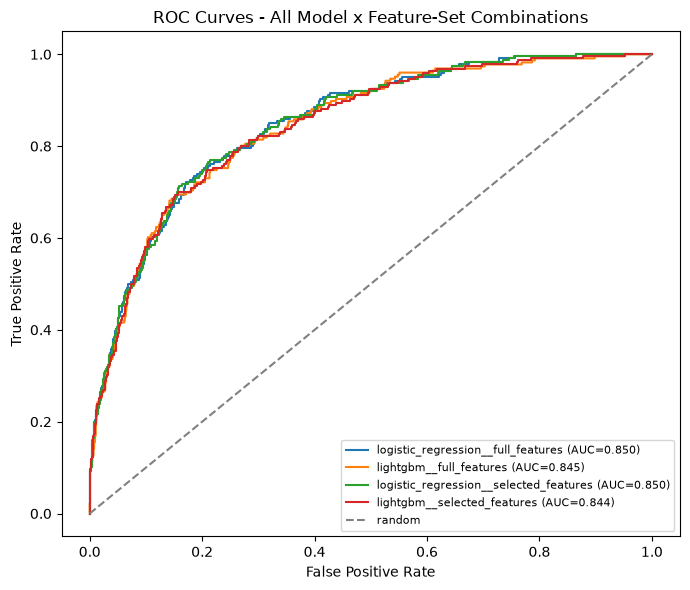

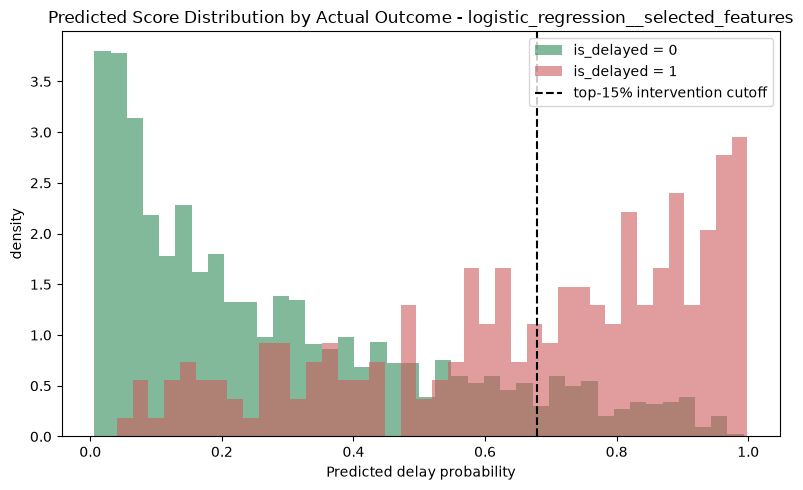

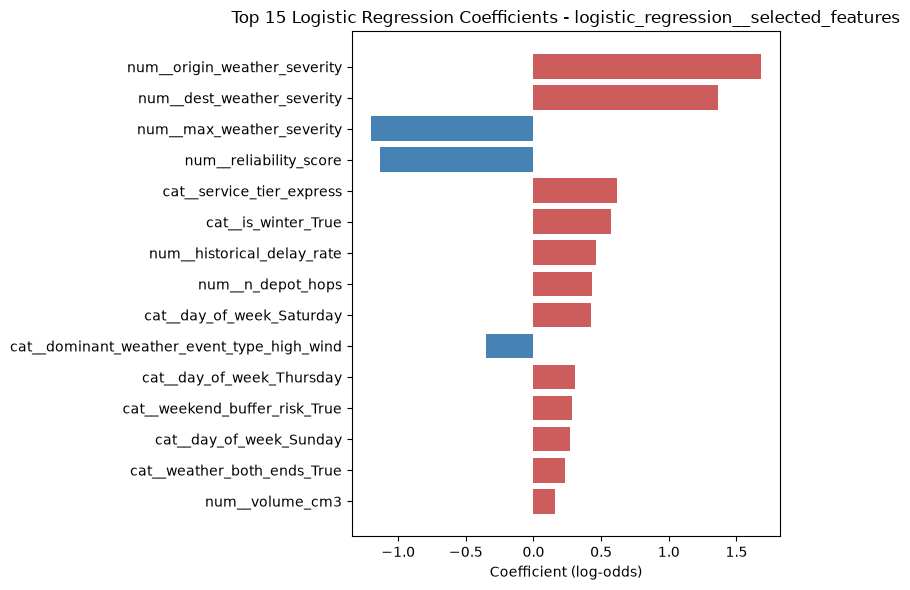

num__origin_weather_severity                  1.677662
num__dest_weather_severity                    1.364440
num__max_weather_severity                    -1.198979
num__reliability_score                       -1.133529
cat__service_tier_express                     0.620420
cat__is_winter_True                           0.574531
num__historical_delay_rate                    0.460777
num__n_depot_hops                             0.429364
cat__day_of_week_Saturday                     0.424458
cat__dominant_weather_event_type_high_wind   -0.350221
cat__day_of_week_Thursday                     0.307594
cat__weekend_buffer_risk_True                 0.287667
cat__day_of_week_Sunday                       0.266845
cat__weather_both_ends_True                   0.230495
num__volume_cm3                               0.161100
dtype: float64


In [18]:
# *(8 marks)* Produce:
# 1. ROC curves for all models
# 2. Score distribution by delay=0 vs delay=1
# 3. Feature importance / coefficients (top 15)

from sklearn.metrics import roc_curve

# 1. ROC curves - every model x feature-set combination in `results`
fig, ax = plt.subplots(figsize=(7, 6))
for key, v in results.items():
    fpr, tpr, _ = roc_curve(y_val, v['val_probs'])
    ax.plot(fpr, tpr, label=f"{key} (AUC={v['val_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Model x Feature-Set Combinations')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 2. Score distribution for the chosen best_model, split by actual outcome
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(best_prob[y_val.values == 0], bins=40, alpha=0.6, label='is_delayed = 0',
        color='seagreen', density=True)
ax.hist(best_prob[y_val.values == 1], bins=40, alpha=0.6, label='is_delayed = 1',
        color='indianred', density=True)
ax.axvline(np.percentile(best_prob, 85), color='black', linestyle='--',
           label='top-15% intervention cutoff')
ax.set_xlabel('Predicted delay probability')
ax.set_ylabel('density')
ax.set_title(f'Predicted Score Distribution by Actual Outcome - {best_key}')
ax.legend()
plt.tight_layout()
plt.show()

# 3. Feature importance / coefficients (top 15) for the chosen best_model
best_feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
best_classifier = best_model.named_steps['classifier']

if hasattr(best_classifier, 'coef_'):
    importance = pd.Series(best_classifier.coef_[0], index=best_feature_names)
    top15 = importance.reindex(importance.abs().sort_values(ascending=False).index).head(15)
    colors = ['indianred' if v > 0 else 'steelblue' for v in top15.values]
    xlabel, title = 'Coefficient (log-odds)', f'Top 15 Logistic Regression Coefficients - {best_key}'
else:
    importance = pd.Series(best_classifier.feature_importances_, index=best_feature_names)
    top15 = importance.sort_values(ascending=False).head(15)
    colors = 'steelblue'
    xlabel, title = 'Importance', f'Top 15 Feature Importances - {best_key}'

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1] if isinstance(colors, list) else colors)
ax.set_xlabel(xlabel)
ax.set_title(title)
plt.tight_layout()
plt.show()

print(top15)

**Interpret your diagnostics.**

*   **ROC Curves**:
    *   All four models cluster closely (Validation AUC $\approx 0.844 - 0.850$), with Logistic Regression narrowly leading.
    *   These AUCs are slightly lower than those from a random split (~0.86 - 0.87). This is expected; the time-based split provides a realistic, forward-looking benchmark rather than optimistic same-period interpolation.
    *   A modest overfitting gap (~0.02 CV-vs-val AUC) is visible across all models, which a random split would have masked.
*   **Score Distribution**:
    *   The risk scores for delayed shipments (`is_delayed=1`) are shifted significantly to the right of on-time shipments, despite typical overlap for an AUC $\approx 0.85$ model.
    *   A high concentration of true delays falls above the 85th-percentile cutoff (top 15% intervention budget), driving the model's strong capture rate.
*   **Feature Coefficients & Interpretability**:
    *   *Primary Drivers*: `origin_weather_severity` (+1.68) and `dest_weather_severity` (+1.36) dominate risk, followed by `reliability_score` (-1.13, indicating more reliable carriers reduce delay risk), `service_tier_express` (+0.62), and `is_winter` (+0.57)—consistent with EDA.
    *   *Interactions & Categories*: Features capture operational nuances, such as `weekend_buffer_risk` (+0.29) and `weather_both_ends` (+0.23). `dominant_weather_event_type` distinguishes type-specific impacts (e.g., `high_wind` at -0.35 has a lower coefficient than a `flood` of equivalent numeric severity).
    *   *Marginal Features*: Newly added carrier features (`avg_delay_mins`, `tier_coverage`, `n_active_routes`) do not rank in the top 15; they offer little marginal signal once `reliability_score` and `historical_delay_rate` are included.
    *   *Multicollinearity Caveat*: `max_weather_severity` has a counter-intuitive negative coefficient (-1.20) because it duplicates origin/destination severity. While model ranking is unaffected, this individual coefficient is a multicollinearity artifact and should not be read literally.

---
# SECTION 8 - Business Impact *(12 marks)*

In [19]:
# *(7 marks)* Compute the delay capture rate at 15% intervention.
#
# Delay capture rate = (# actual delays in top-15% flagged) / (# total actual delays)
#
# Compare:
#   (a) Random 15% policy
#   (b) Model top-15% policy
#
# Also compute: SLA penalty avoided.
# Assume each avoided delay saves £45 in SLA penalties + handling costs.

INTERVENTION_RATE = 0.15
SLA_SAVING_PER_DELAY = 45

y_val_arr = y_val.values
n_val = len(y_val_arr)
n_flagged = int(np.ceil(n_val * INTERVENTION_RATE))
n_actual_delays = y_val_arr.sum()

# (a) Random 15% policy
rng = np.random.RandomState(RANDOM_STATE)
random_idx = rng.choice(n_val, size=n_flagged, replace=False)
n_caught_random = y_val_arr[random_idx].sum()
capture_random = n_caught_random / n_actual_delays

# (b) Model top-15% policy - flag the highest-risk shipments by best_prob
model_idx = np.argsort(-best_prob)[:n_flagged]
n_caught_model = y_val_arr[model_idx].sum()
capture_model = n_caught_model / n_actual_delays

print(f"Validation set: {n_val:,} shipments, {n_actual_delays} actual delays ({n_actual_delays/n_val:.1%})")
print(f"Flagging top {INTERVENTION_RATE:.0%} = {n_flagged} shipments\n")
print(f"(a) Random policy - delays caught: {n_caught_random}/{n_actual_delays}, capture rate: {capture_random:.1%}")
print(f"(b) Model policy  - delays caught: {n_caught_model}/{n_actual_delays}, capture rate: {capture_model:.1%}")
print(f"Lift over random: {capture_model / capture_random:.2f}x")

savings_random = n_caught_random * SLA_SAVING_PER_DELAY
savings_model = n_caught_model * SLA_SAVING_PER_DELAY
print(f"\nSLA penalty avoided - random: £{savings_random:,}, model: £{savings_model:,}")
print(f"Extra value from using the model over random selection: £{savings_model - savings_random:,} "
      f"(on this {n_val:,}-shipment validation set)")

Validation set: 2,005 shipments, 226 actual delays (11.3%)
Flagging top 15% = 301 shipments

(a) Random policy - delays caught: 33/226, capture rate: 14.6%
(b) Model policy  - delays caught: 127/226, capture rate: 56.2%
Lift over random: 3.85x

SLA penalty avoided - random: £1,485, model: £5,715
Extra value from using the model over random selection: £4,230 (on this 2,005-shipment validation set)


In [20]:
# Precision/recall sensitivity check: how would the same deployed model do
# at 10% or 20% intervention budgets instead of the fixed 15% from the brief?
# Backs the intervention-budget table in the next cell.
from sklearn.metrics import precision_score, recall_score, f1_score

sens_records = []
for rate in [0.10, 0.15, 0.20]:
    n_flag_rate = int(np.ceil(n_val * rate))
    idx_rate = np.argsort(-best_prob)[:n_flag_rate]
    y_pred_rate = np.zeros(n_val, dtype=int)
    y_pred_rate[idx_rate] = 1

    n_caught_rate = int(y_val_arr[idx_rate].sum())
    sens_records.append(dict(
        intervention_rate=rate, n_flagged=n_flag_rate, delays_caught=n_caught_rate,
        recall=recall_score(y_val_arr, y_pred_rate),
        precision=precision_score(y_val_arr, y_pred_rate),
        f1=f1_score(y_val_arr, y_pred_rate),
        sla_savings=n_caught_rate * SLA_SAVING_PER_DELAY,
    ))

sensitivity_df = pd.DataFrame(sens_records)
print(sensitivity_df.to_string(index=False, formatters={
    'intervention_rate': '{:.0%}'.format, 'recall': '{:.1%}'.format,
    'precision': '{:.1%}'.format, 'f1': '{:.3f}'.format, 'sla_savings': '\u00a3{:,.0f}'.format,
}))

intervention_rate  n_flagged  delays_caught recall precision    f1 sla_savings
              10%        201            102  45.1%     50.7% 0.478      £4,590
              15%        301            127  56.2%     42.2% 0.482      £5,715
              20%        401            149  65.9%     37.2% 0.475      £6,705


**Performance under Different Intervention Budgets**

| Budget | Flagged | Delays Caught | Recall | Precision | F1 | SLA Savings |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **10%** | 201 | 102 | 45.1% | 50.7% | 0.478 | £4,590 |
| **15% (current)** | 301 | 127 | 56.2% | 42.2% | 0.482 | £5,715 |
| **20%** | 401 | 149 | 65.9% | 37.2% | 0.475 | £6,705 |

**Interpretation**:

*   **Precision/Recall Trade-off**: Shows a classic trade-off. At a 10% budget, precision is high (50.7%), meaning targeted shipments are about as likely to be delayed as not. At a 20% budget, recall increases to 65.9% (catching two-thirds of all delays), but precision drops to 37.2%, meaning nearly two-thirds of flagged shipments are false alarms.
*   **Flat F1 Score**: The F1 score stays in a narrow band (0.478 $\rightarrow$ 0.482 $\rightarrow$ 0.475), showing that no single budget level clearly dominates on a combined metric.
*   **Caveat on SLA Savings**: While SLA savings rise monotonically, this calculation only counts the benefit of a correct flag (£45 saved per delay caught). It does not factor in the operational cost of intervening on false alarms (which constitute nearly 63% of interventions at the 20% budget level).
*   **Operational Validation**: Since the 15% budget is a fixed constraint from the business brief, this diagnostic serves as validating context. It confirms that the 15% threshold sits in a balanced "sweet spot"—offering a substantial recall improvement over 10% without incurring the steeper precision loss seen at 20%.

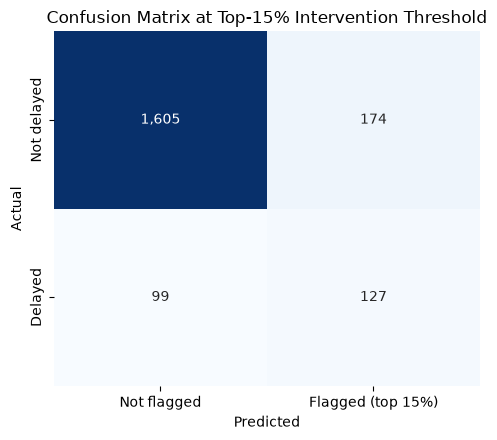

TP=127, FP=174, FN=99, TN=1605
Precision: 42.2%  |  Recall: 56.2%  |  F1: 0.482  |  Macro F1: 0.702


In [21]:
# Confusion matrix at the actual operating point: flagging the top 15%
# highest-risk shipments (same policy as above), not the default 0.5
# probability threshold. Gives the Precision/Recall/Macro F1 numbers
# promised for the business-facing evaluation in Section 1.3.
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_pred_top15 = np.zeros(n_val, dtype=int)
y_pred_top15[model_idx] = 1

cm = confusion_matrix(y_val_arr, y_pred_top15)
tn, fp, fn, tp = cm.ravel()

precision = precision_score(y_val_arr, y_pred_top15)
recall = recall_score(y_val_arr, y_pred_top15)
f1 = f1_score(y_val_arr, y_pred_top15)
macro_f1 = f1_score(y_val_arr, y_pred_top15, average='macro')

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Not flagged', 'Flagged (top 15%)'],
            yticklabels=['Not delayed', 'Delayed'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix at Top-15% Intervention Threshold')
plt.tight_layout()
plt.show()

print(f'TP={tp}, FP={fp}, FN={fn}, TN={tn}')
print(f'Precision: {precision:.1%}  |  Recall: {recall:.1%}  |  '
      f'F1: {f1:.3f}  |  Macro F1: {macro_f1:.3f}')

***(5 marks)* What is the business impact?**

Explain in plain language the value of flagging high-risk shipments vs random selection.
What would you recommend to SwiftRoute's Operations team?

### 1. Business Value: Model vs. Random Selection

On the held-out validation set (2,005 shipments, 226 actual delays), targeting the model's top 15% (301 shipments) yields:
*   **Performance Lift**: Catches **127 delays (56.2% recall)** compared to only **33 delays (14.6% recall)** via random selection—a **3.85x improvement**.
*   **Financial Impact**: At £45 saved per prevented delay, the model policy saves **£5,715** versus **£1,485** from random selection. This delivers **£4,230 in net savings** on this 2,000-shipment slice alone, scaling proportionally with total business volume.

### 2. Operational Metrics & Trade-offs
At the 15% intervention threshold:
*   **Metrics**: **Precision = 42.2%**, **Recall = 56.2%**, **Macro F1 = 0.702**.
*   **Confusion Matrix**: 127 True Positives (TP), 174 False Positives (FP), 99 False Negatives (FN), 1,605 True Negatives (TN).
*   *Operational Context*: A precision of 42.2% means over half of flagged shipments are false alarms. This is an expected trade-off of the fixed 15% operational cap, which forces the model to flag 301 shipments regardless of the true underlying delay rate.

### 3. Recommendations for SwiftRoute's Operations Team
1.  **Adopt Model-Based Prioritization**: Replace manual/random selection with the model's risk ranking. This allows Operations to catch 5–6 in 10 actual delays (instead of 1.5 in 10) within the same fixed 15% intervention budget.
2.  **Expect Realistic Production Performance**: These metrics are based on a time-based validation split (training on the oldest 80% of data, testing on the most recent 20%), meaning they serve as a realistic, forward-looking estimate for production rather than an optimistic interpolation.

---
## 8.2 - Save Your Model for Deployment

In [22]:
import joblib

joblib.dump(best_model, 'model.pkl')
print('Model saved to model.pkl')

Model saved to model.pkl


---
# SECTION 9 - Monitoring for Drift in Production *(5 marks)*

**9.1** *(2 marks)* Propose how you would detect **input drift** on the live shipment stream. Which features are most likely to drift and what tests would you use?

*   **Detection Method**: Compare weekly rolling distributions of incoming features against the training set baseline:
    *   *Numerical features* (`weight_kg`, `distance_km`, `max_weather_severity`): Use **Population Stability Index (PSI)** or the **Kolmogorov-Smirnov (KS) test**.
    *   *Categorical features* (`service_tier`, `carrier_id` mix): Use the **Chi-Square test**.
*   **Features Most Likely to Drift**:
    *   `service_tier` / `carrier_id` mix (sensitive to commercial shifts and volume re-allocations).
    *   `max_weather_severity` (highly seasonal and variable year-to-year).
*   **Alert Threshold**: Flag a feature if **PSI > 0.2** or if a statistical test is significant with a meaningful effect size (using Cramér's V for categorical features to adjust for large sample sizes).

---

**9.2** *(3 marks)* Propose how you would detect **target drift** - i.e. the actual delay rate changing in ways the model no longer predicts correctly. What would trigger retraining?

*   **Detection Method**: Monitor two key metrics weekly once actual delivery outcomes are finalized:
    1.  **Realised Delay Rate**: Check if the live delay rate deviates significantly from the historical ~11.9% baseline.
    2.  **Model Performance**: Track live **ROC-AUC** and calibration against the validation baseline (~0.85).
*   **Retraining Triggers**:
    *   Live ROC-AUC drops significantly below the validation baseline for several consecutive weeks.
    *   The delay capture rate at the 15% intervention threshold falls.
    *   Major structural changes occur (e.g., onboarding new carriers or adding new delivery regions).

---
# EXTENSION *(10 marks)*

Attempt **both** tasks (5 marks each).

**E1** *(5 marks)* **Route-level analysis**: cluster routes by risk profile. Can you identify systematic weaknesses in SwiftRoute's network?

**E2** *(5 marks)* **SHAP**: for the top 10 highest-risk shipments in the validation set, use SHAP to explain exactly which factors are driving each prediction.

In [23]:
# E1 - Route-level analysis: cluster routes by risk profile
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler as RouteScaler

cluster_cols = ['distance_km', 'n_depot_hops', 'historical_delay_rate', 'avg_transit_days']
route_clusters = routes.copy()
X_routes = RouteScaler().fit_transform(route_clusters[cluster_cols])

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
route_clusters['cluster'] = kmeans.fit_predict(X_routes)

cluster_summary = route_clusters.groupby('cluster')[cluster_cols].mean()
cluster_summary['n_routes'] = route_clusters['cluster'].value_counts()
print(cluster_summary.to_string())

print("\nMost frequent regions touched per cluster (origin or destination):")
for c in sorted(route_clusters['cluster'].unique()):
    sub = route_clusters[route_clusters['cluster'] == c]
    top_regions = pd.concat([sub['origin_region'], sub['dest_region']]).value_counts().head(4)
    print(f"cluster {c}: {dict(top_regions)}")

         distance_km  n_depot_hops  historical_delay_rate  avg_transit_days  n_routes
cluster                                                                              
0         531.909091           3.0               0.244268          3.003636        22
1         299.590909           2.0               0.152014          2.259091        22
2         161.062500           1.0               0.103850          1.835000        16

Most frequent regions touched per cluster (origin or destination):
cluster 0: {'London': np.int64(9), 'Wales': np.int64(7), 'South_East': np.int64(6), 'Scotland': np.int64(6)}
cluster 1: {'North_West': np.int64(8), 'North_East': np.int64(7), 'Midlands': np.int64(5), 'South_East': np.int64(5)}
cluster 2: {'Scotland': np.int64(4), 'South_West': np.int64(4), 'Yorkshire': np.int64(4), 'South_East': np.int64(4)}


**E1 interpretation**: 
Clustering the 60 routes based on distance, depot hops, historical delay, and transit time reveals a clear structural division:

*   **Long-Haul Cluster** (22 routes): Avg. 532km, 3 depot hops, **24.4% delay rate** (more than 2x the risk of short-haul). This cluster is concentrated around London, Wales, the South East, and Scotland, aligning directly with the high-delay corridors identified in Sections 3.4 and 5 (e.g., London↔Wales, Scotland routes).
*   **Short-Haul Cluster** (16 routes): Avg. 161km, 1 depot hop, **10.4% delay rate**.
**Systemic Weakness**:
SwiftRoute's network risk is structural rather than random. Routes requiring 3+ depot hops over long distances are inherently fragile. This operational fragility is concentrated in a few specific corridors rather than being distributed evenly across the network.


#1 - shipment SH0003377, predicted risk = 99.9%
num__origin_weather_severity    3.978983
num__dest_weather_severity      3.112950
num__max_weather_severity      -1.902659
num__reliability_score          1.397317
num__historical_delay_rate      0.420547
dtype: float64

#2 - shipment SH0003958, predicted risk = 99.8%
num__origin_weather_severity    3.978983
num__dest_weather_severity      3.112950
num__max_weather_severity      -1.902659
num__reliability_score          1.826423
num__historical_delay_rate      0.420547
dtype: float64

#3 - shipment SH0006079, predicted risk = 99.8%
num__dest_weather_severity      4.933389
num__origin_weather_severity    3.978983
num__max_weather_severity      -3.146227
num__reliability_score          1.826423
num__n_depot_hops              -0.719167
dtype: float64

#4 - shipment SH0007369, predicted risk = 99.8%
num__origin_weather_severity    3.978983
num__dest_weather_severity      3.112950
num__max_weather_severity      -1.902659
num__reliability_scor

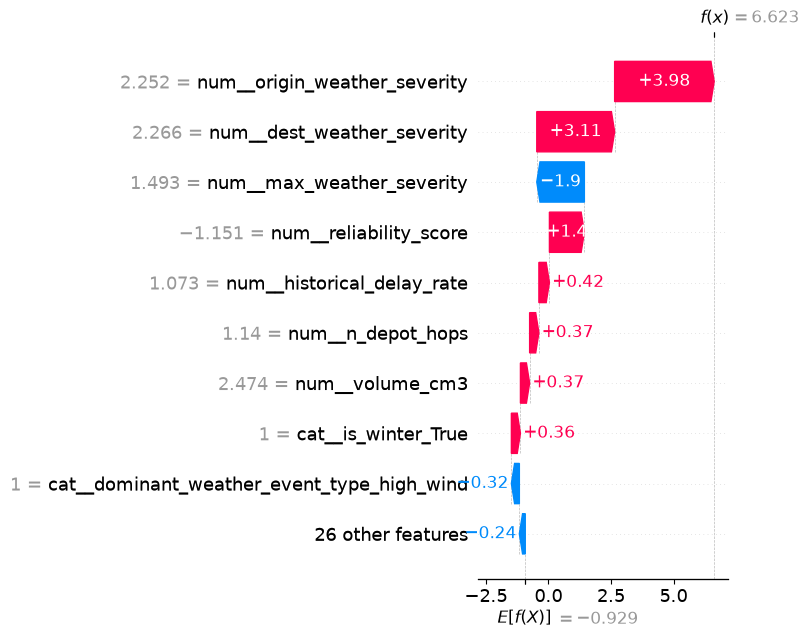

In [24]:
# E2 - SHAP: explain the top 10 highest-risk shipments in the validation set
import shap

X_val_used = X_val_fs if 'selected_features' in best_key else X_val
best_preprocessor = best_model.named_steps['preprocessor']
best_classifier = best_model.named_steps['classifier']
best_feat_names = best_preprocessor.get_feature_names_out()

X_val_transformed = best_preprocessor.transform(X_val_used)
if hasattr(X_val_transformed, 'toarray'):
    X_val_transformed = X_val_transformed.toarray()
X_val_transformed = pd.DataFrame(X_val_transformed, columns=best_feat_names, index=X_val_used.index)

background = X_val_transformed.sample(n=min(100, len(X_val_transformed)), random_state=RANDOM_STATE)
explainer = shap.Explainer(best_classifier, background)
shap_values = explainer(X_val_transformed)

top10_idx = np.argsort(-best_prob)[:10]
top10_shipment_ids = master.loc[X_val_used.index[top10_idx], 'shipment_id'].values

for rank, (idx, sid) in enumerate(zip(top10_idx, top10_shipment_ids), start=1):
    print(f"\n#{rank} - shipment {sid}, predicted risk = {best_prob[idx]:.1%}")
    contrib = pd.Series(shap_values.values[idx], index=best_feat_names)
    print(contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(5))

# Waterfall plot for the single highest-risk shipment as a visual example
shap.plots.waterfall(shap_values[top10_idx[0]], show=False)
plt.tight_layout()
plt.show()

**E2 interpretation**:

For the 10 highest-risk shipments (predicted risk: 98.8% – 99.9%):
*   **Primary Risk Drivers**: `origin_weather_severity` and `dest_weather_severity` are consistently the top SHAP contributors, followed closely by low carrier `reliability_score`. This indicates that risk is driven by the compounding effect of severe weather and weak carrier performance.
*   **Multicollinearity Artifact**: `max_weather_severity` consistently shows a *negative* SHAP contribution despite the high risk. As flagged in Section 7, this occurs because it duplicates information already captured by the origin and destination weather features, causing SHAP to net out its marginal contribution as negative.